# Comprehensive Report: Solar Power Prediction Analysis
## Statistical Analysis & Neural Network Modeling

**Project:** Harmonic Solar Power Dataset Analysis  
**Objective:** Determine whether Power [kW] can be predicted from Date features and POA Irradiance [W/m²]  
**Data Source:** "hourly data set 8 12 2025.xlsx" — 13 monthly sheets (Sept 2024 – Sept 2025)  
**Methods:** ANOVA, Hypothesis Testing, Correlation Analysis, Linear Regression, Neural Network with Hyperparameter Optimization

---

### Table of Contents
1. Import Libraries & Setup
2. Data Loading & Preparation
3. Data Overview & Summary Statistics
4. Missing Values Analysis & Handling
5. Univariate Analysis — Distribution Plots
6. Bivariate Analysis — Scatter & Box Plots
7. Correlation Analysis — Heatmap
8. Time Series & Trend Analysis
9. Outlier Detection & Visualization
10. ANOVA Tests — Detailed Results
11. Hypothesis Tests — Full Suite
12. Linear Regression Analysis
13. Neural Network — Architecture & Training
14. Model Comparison — All Methods
15. Key Findings Summary
16. Export Report Artifacts

---
## 1. Import Required Libraries

We use **pandas** for data manipulation, **numpy** for numerical operations, **scipy** for statistical tests, **matplotlib/seaborn** for visualization, **scikit-learn** for regression, and **PyTorch + Optuna** for neural network training with hyperparameter optimization.

In [1]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import warnings, os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries loaded successfully!")
print(f"PyTorch: {torch.__version__} | Optuna: {optuna.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

All libraries loaded successfully!
PyTorch: 2.10.0+cpu | Optuna: 4.7.0
Device: CPU


c:\Users\AbdulSaleem.Shaik\Desktop\harmonic-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Data Loading & Preparation

The dataset is stored in an Excel workbook with **13 separate sheets** — one per month from September 2024 through September 2025. Each sheet contains hourly measurements of solar power output and environmental variables.

**Loading Strategy:** Read all sheets, identify common columns, and concatenate into one unified DataFrame.

In [2]:
# ============================================================
# 2. LOAD DATA FROM ALL SHEETS
# ============================================================
xlsx = pd.ExcelFile('hourly data set 8 12 2025.xlsx')
print(f'Excel workbook contains {len(xlsx.sheet_names)} sheets:\n')

all_dfs = []
for sheet in xlsx.sheet_names:
    tmp = pd.read_excel(xlsx, sheet_name=sheet)
    all_dfs.append(tmp)
    print(f'  {sheet:>15s}: {tmp.shape[0]:>4d} rows x {tmp.shape[1]:>2d} columns')

# Common columns across all sheets
common_cols = set(all_dfs[0].columns)
for d in all_dfs[1:]:
    common_cols = common_cols & set(d.columns)
common_cols = sorted(common_cols)

df_raw = pd.concat([d[common_cols] for d in all_dfs], ignore_index=True)
print(f'\n{"="*60}')
print(f'Combined Dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Common columns ({len(common_cols)}): {common_cols}')
print(f'{"="*60}')

Excel workbook contains 13 sheets:

  sept hourly 2024:  720 rows x 16 columns
  oct hourly 2024:  744 rows x 16 columns
  nov hourly 2024:  720 rows x 16 columns
  dec hourly 2024:  744 rows x 16 columns
  jan hourly 2025 :  744 rows x 16 columns
  feb hourly 2025:  672 rows x 16 columns
  march hourly 2025:  744 rows x 16 columns
  april hourly 2025:  720 rows x 16 columns
  may hourly 2025:  744 rows x 16 columns
  june hourly 2025:  720 rows x 12 columns
  july hourly 2025:  744 rows x 16 columns
  august hourly 2025:  744 rows x 16 columns
  sept hourly 2025:  720 rows x 16 columns

Combined Dataset: 9,480 rows x 11 columns
Common columns (11): ['Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]', 'Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Date', 'Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Voltage DC (INV-1 Huawei SUN2000-60KT

---
## 3. Data Overview & Summary Statistics

### Key Columns:
| Column | Description |
|--------|-------------|
| **Date** | Timestamp of the measurement (hourly intervals) |
| **Power [kW]** | Solar power output in kilowatts — **target variable** |
| **POA irradiance (sensor) [W/m²]** | Plane-of-Array irradiance — measures sunlight hitting the panels |

Solar power data spans over 13 months with hourly resolution. Power output varies with time of day (zero at night), season, and weather conditions.

In [3]:
# ============================================================
# 3. DATA OVERVIEW & SUMMARY STATISTICS
# ============================================================
date_col = 'Date'
power_col = 'Power [kW]'
poa_col = 'POA irradiance (sensor) [W/m²]'

df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df_raw[power_col] = pd.to_numeric(df_raw[power_col], errors='coerce')
df_raw[poa_col] = pd.to_numeric(df_raw[poa_col], errors='coerce')

print("DATA INFO:")
print(f"  Shape: {df_raw.shape}")
print(f"  Date range: {df_raw[date_col].min()} → {df_raw[date_col].max()}")
print(f"  Duration: {(df_raw[date_col].max() - df_raw[date_col].min()).days} days")
print(f"\nData Types:")
print(df_raw.dtypes.to_string())
print(f'\n{"="*60}')
print("DESCRIPTIVE STATISTICS:")
print(f'{"="*60}')
display(df_raw.describe().round(2))
print(f'\nFirst 5 rows:')
display(df_raw.head())
print(f'\nLast 5 rows:')
display(df_raw.tail())

DATA INFO:
  Shape: (9480, 11)
  Date range: 2024-09-01 00:00:00 → 2025-12-31 23:00:00
  Duration: 486 days

Data Types:
Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]                              object
Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]                               object
Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]                              object
Date                                                                datetime64[us]
Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp]            object
Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp]             object
Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp]            object
POA irradiance (sensor) [W/m²]                                             float64
Power [kW]                                                                 float64
Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V]                               object
Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V]    

,Date,POA irradiance (sensor) [W/m²],Power [kW]
count,9480,8881.00,8931.00
mean,2025-07-08 04:11:46.329114,171.64,18.13
min,2024-09-01 00:00:00,0.00,0.00
25%,2025-04-09 16:45:00,0.01,0.00
50%,2025-07-17 10:30:00,7.62,0.46
75%,2025-09-27 14:15:00,327.26,37.34
max,2025-12-31 23:00:00,1002.42,90.54
std,NaN,247.56,24.82



First 5 rows:


,Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A],Current AC (INV2 Huawei SUN2000-60KTL-M0) [A],Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A],Date,Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp],POA irradiance (sensor) [W/m²],Power [kW],Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V],Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V]
0,0.0,0.0,0.0,2024-09-01 00:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
1,0.0,0.0,0.0,2025-09-01 01:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
2,0.0,0.0,0.0,2025-09-01 02:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
3,0.0,0.0,0.0,2025-09-01 03:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
4,0.0,0.0,0.0,2025-09-01 04:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0



Last 5 rows:


,Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A],Current AC (INV2 Huawei SUN2000-60KTL-M0) [A],Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A],Date,Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp],POA irradiance (sensor) [W/m²],Power [kW],Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V],Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V]
9475,0.02,0.01,0.03,2025-09-30 19:00:00,0.03,0.01,174.66,0.51,0.0,108.04,180.41
9476,0.0,0.0,0.0,2025-09-30 20:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
9477,0.0,0.0,0.0,2025-09-30 21:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
9478,0.0,0.0,0.0,2025-09-30 22:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0
9479,0.0,0.0,0.0,2025-09-30 23:00:00,0.0,0.0,0.0,0.01,0.0,0.0,0.0


---
## 4. Missing Values Analysis & Handling

Missing values in sensor data arise from equipment failures, communication errors, or maintenance. Our approach:
- Rows with missing **Power** or **POA irradiance** are **dropped** (not imputed) to ensure analysis uses only actual measurements
- **Duplicate rows** are removed to prevent bias

MISSING VALUES ANALYSIS

Columns with missing values:


,Missing Count,Missing %
POA irradiance (sensor) [W/m²],599,6.32
Power [kW],549,5.79
Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V],1,0.01


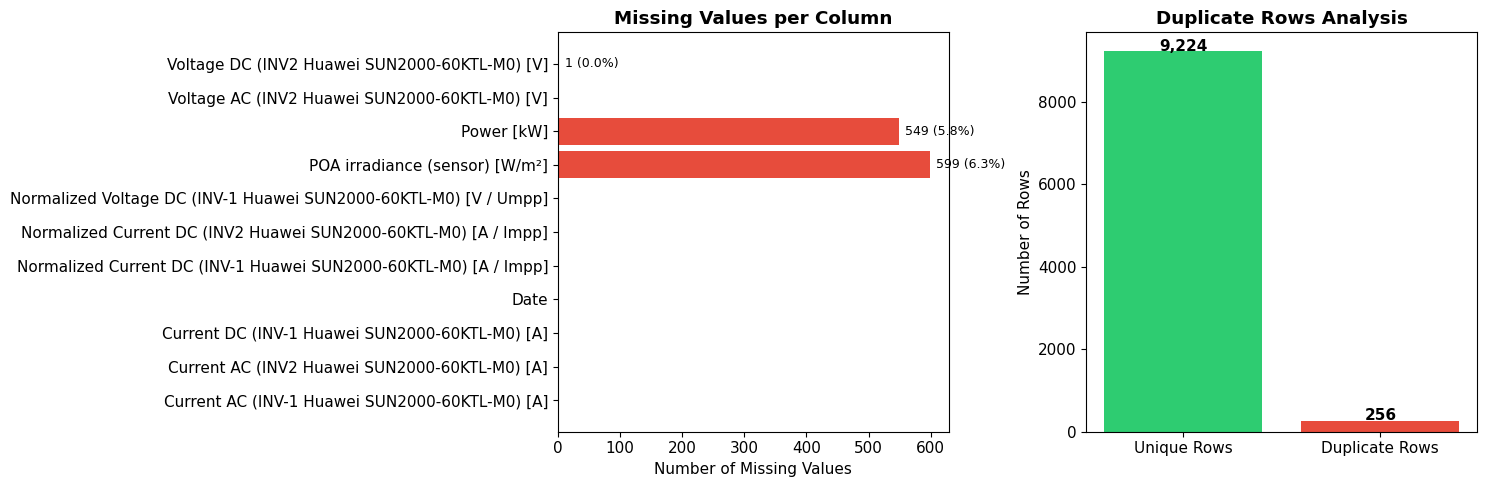


Before cleaning: 9,480 rows
After dropping NaN: 8,881 rows
After removing duplicates: 8,621 rows

✅ Final clean dataset: 8,621 rows (90.9% retained)


In [4]:
# ============================================================
# 4. MISSING VALUES ANALYSIS & HANDLING
# ============================================================
print("MISSING VALUES ANALYSIS")
print("="*60)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_df) > 0:
    print("\nColumns with missing values:")
    display(missing_df)
else:
    print("\nNo missing values found.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
all_missing = df_raw.isnull().sum()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in all_missing]
axes[0].barh(all_missing.index, all_missing.values, color=colors)
axes[0].set_xlabel('Number of Missing Values')
axes[0].set_title('Missing Values per Column', fontweight='bold')
for i, (v, name) in enumerate(zip(all_missing.values, all_missing.index)):
    if v > 0:
        axes[0].text(v + 10, i, f'{v} ({v/len(df_raw)*100:.1f}%)', va='center', fontsize=9)

dup_count = df_raw.duplicated().sum()
axes[1].bar(['Unique Rows', 'Duplicate Rows'], [len(df_raw) - dup_count, dup_count], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Duplicate Rows Analysis', fontweight='bold')
axes[1].set_ylabel('Number of Rows')
for i, v in enumerate([len(df_raw) - dup_count, dup_count]):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('report_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean data
df = df_raw[[date_col, power_col, poa_col]].copy()
print(f'\nBefore cleaning: {len(df):,} rows')
df = df.dropna()
print(f'After dropping NaN: {len(df):,} rows')
df = df.drop_duplicates().reset_index(drop=True)
print(f'After removing duplicates: {len(df):,} rows')
print(f'\n✅ Final clean dataset: {len(df):,} rows ({len(df)/len(df_raw)*100:.1f}% retained)')

---
## 5. Univariate Analysis — Distribution Plots

### Key Insight:
Solar power data is highly **non-normal** — it has a large spike at zero (nighttime hours when no power is produced) and a right-skewed tail of daytime production values. This bimodal nature is critical for choosing appropriate statistical tests and modeling approaches.

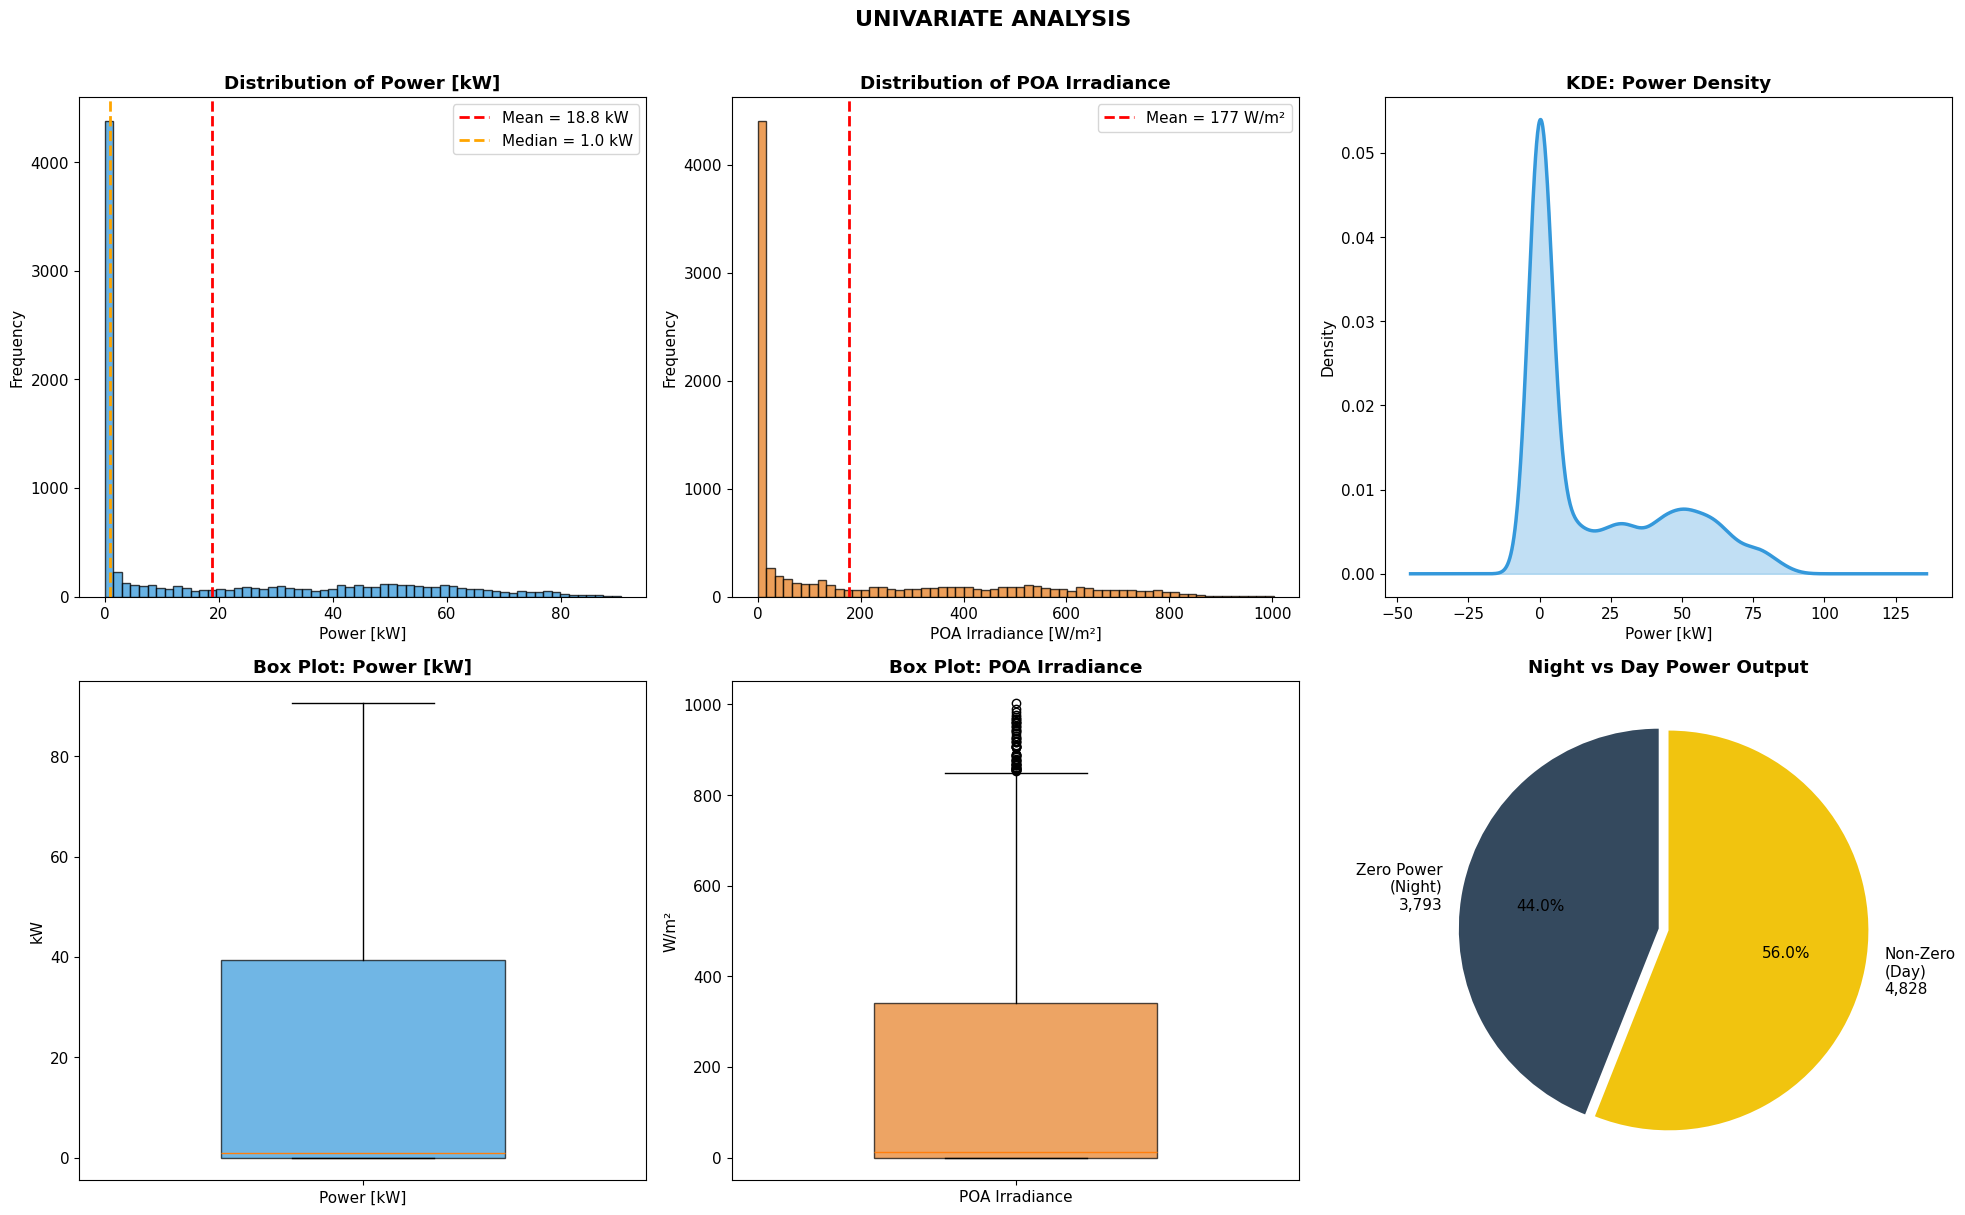


DETAILED STATISTICS:
Metric                         Power [kW]      POA [W/m²]
------------------------------------------------------------
  Mean                              18.78          176.82
  Std Dev                           25.02          249.43
  Min                                0.00            0.00
  Median                             0.97           12.34
  Max                               90.54         1002.42
  Skewness                           1.01            1.21
  Kurtosis                          -0.41            0.13
  Zero Values                       3,793             233


In [5]:
# ============================================================
# 5. UNIVARIATE ANALYSIS — DISTRIBUTION PLOTS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0,0].hist(df[power_col], bins=60, edgecolor='black', alpha=0.75, color='#3498db')
axes[0,0].axvline(df[power_col].mean(), color='red', linestyle='--', lw=2, label=f'Mean = {df[power_col].mean():.1f} kW')
axes[0,0].axvline(df[power_col].median(), color='orange', linestyle='--', lw=2, label=f'Median = {df[power_col].median():.1f} kW')
axes[0,0].set_xlabel('Power [kW]'); axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Power [kW]', fontweight='bold'); axes[0,0].legend()

axes[0,1].hist(df[poa_col], bins=60, edgecolor='black', alpha=0.75, color='#e67e22')
axes[0,1].axvline(df[poa_col].mean(), color='red', linestyle='--', lw=2, label=f'Mean = {df[poa_col].mean():.0f} W/m²')
axes[0,1].set_xlabel('POA Irradiance [W/m²]'); axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of POA Irradiance', fontweight='bold'); axes[0,1].legend()

df[power_col].plot(kind='kde', ax=axes[0,2], color='#3498db', linewidth=2.5)
axes[0,2].fill_between(axes[0,2].lines[0].get_xdata(), axes[0,2].lines[0].get_ydata(), alpha=0.3, color='#3498db')
axes[0,2].set_xlabel('Power [kW]'); axes[0,2].set_ylabel('Density')
axes[0,2].set_title('KDE: Power Density', fontweight='bold')

bp = axes[1,0].boxplot([df[power_col]], labels=['Power [kW]'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
axes[1,0].set_ylabel('kW'); axes[1,0].set_title('Box Plot: Power [kW]', fontweight='bold')

bp2 = axes[1,1].boxplot([df[poa_col]], labels=['POA Irradiance'], patch_artist=True, widths=0.5)
bp2['boxes'][0].set_facecolor('#e67e22'); bp2['boxes'][0].set_alpha(0.7)
axes[1,1].set_ylabel('W/m²'); axes[1,1].set_title('Box Plot: POA Irradiance', fontweight='bold')

zero_power = (df[power_col] == 0).sum()
nonzero_power = (df[power_col] > 0).sum()
axes[1,2].pie([zero_power, nonzero_power], 
              labels=[f'Zero Power\n(Night)\n{zero_power:,}', f'Non-Zero\n(Day)\n{nonzero_power:,}'],
              colors=['#34495e', '#f1c40f'], autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
axes[1,2].set_title('Night vs Day Power Output', fontweight='bold')

plt.suptitle('UNIVARIATE ANALYSIS', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('report_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDETAILED STATISTICS:")
print(f"{'Metric':<25} {'Power [kW]':>15} {'POA [W/m²]':>15}")
print("-"*60)
for name, func in [('Mean','mean'),('Std Dev','std'),('Min','min'),('Median','median'),('Max','max'),('Skewness','skew'),('Kurtosis','kurt')]:
    v1, v2 = getattr(df[power_col], func)(), getattr(df[poa_col], func)()
    print(f"  {name:<23} {v1:>15.2f} {v2:>15.2f}")
print(f"  {'Zero Values':<23} {(df[power_col]==0).sum():>15,} {(df[poa_col]==0).sum():>15,}")

---
## 6. Bivariate Analysis & Feature Engineering

### Features Created from Date:
- **Hour, Month, DayOfYear, DayOfWeek, WeekOfYear** — direct time features
- **Sunlight** (binary) — 1 if POA irradiance > 0, else 0 (indicates sun availability)
- **Cyclical encoding** — sin/cos transforms for Hour, Month, DayOfYear to capture circular nature (Hour 23 is close to Hour 0)

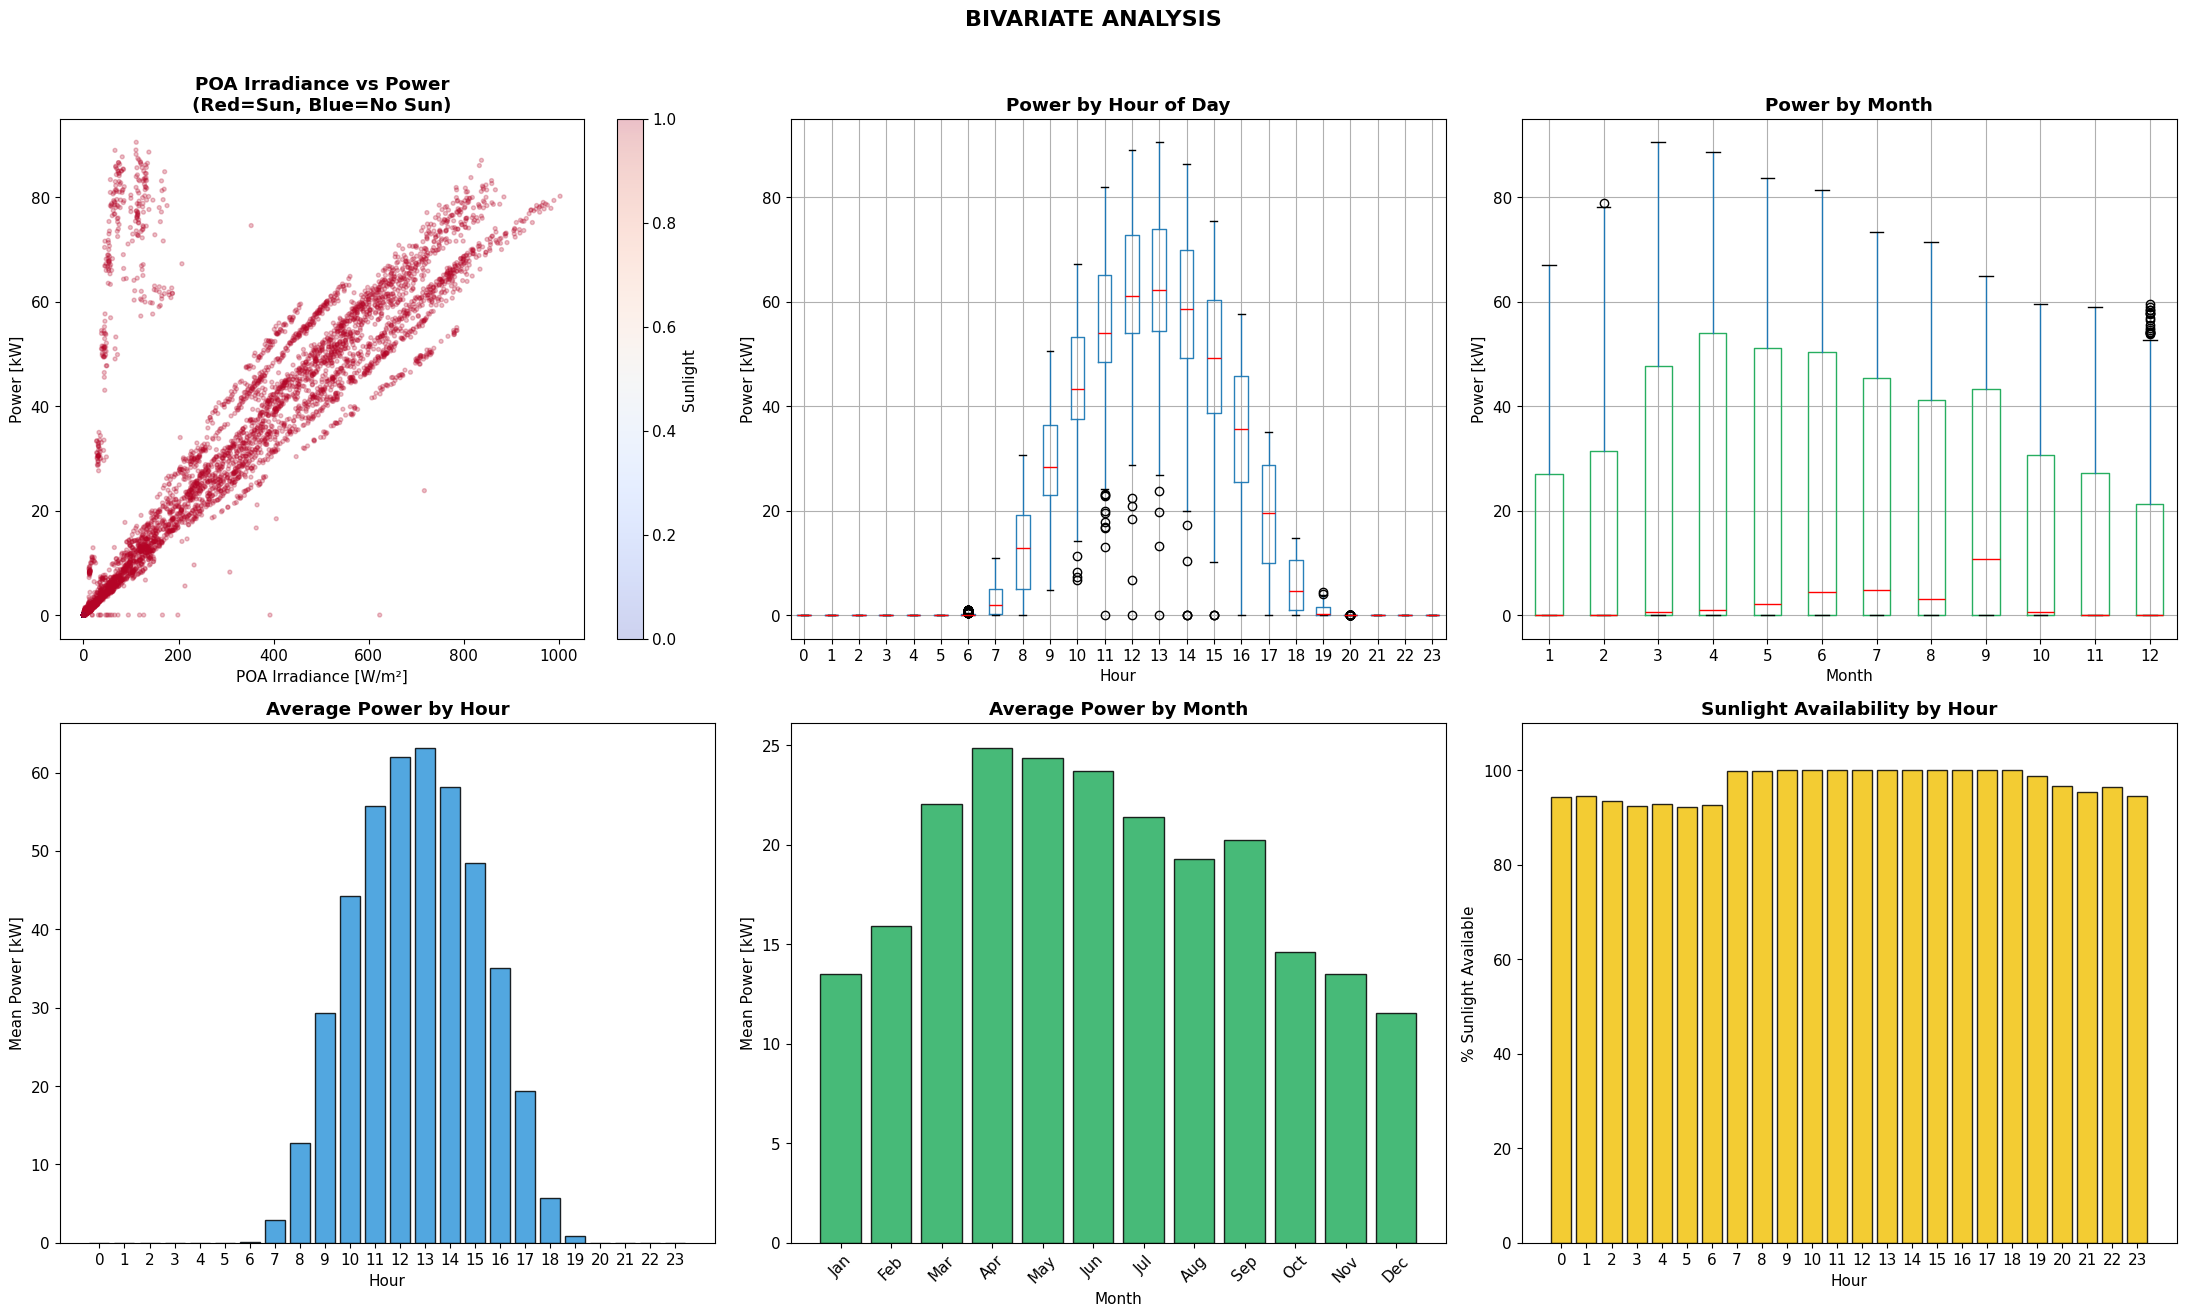


Sunlight: 8,388 hours with sun / 233 without
Features created: 13


In [6]:
# ============================================================
# 6. FEATURE ENGINEERING & BIVARIATE ANALYSIS
# ============================================================
df['Sunlight'] = (df[poa_col] > 0).astype(int)
df['Hour'] = df[date_col].dt.hour
df['Month'] = df[date_col].dt.month
df['DayOfYear'] = df[date_col].dt.dayofyear
df['DayOfWeek'] = df[date_col].dt.dayofweek
df['WeekOfYear'] = df[date_col].dt.isocalendar().week.astype(int)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
df['Timestamp_h'] = (df[date_col] - df[date_col].min()).dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

scatter = axes[0,0].scatter(df[poa_col], df[power_col], alpha=0.25, s=8, c=df['Sunlight'], cmap='coolwarm')
axes[0,0].set_xlabel('POA Irradiance [W/m²]'); axes[0,0].set_ylabel('Power [kW]')
axes[0,0].set_title('POA Irradiance vs Power\n(Red=Sun, Blue=No Sun)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0,0], label='Sunlight')

df.boxplot(column=power_col, by='Hour', ax=axes[0,1], boxprops=dict(color='#2980b9'), medianprops=dict(color='red'))
axes[0,1].set_title('Power by Hour of Day', fontweight='bold')
axes[0,1].set_xlabel('Hour'); axes[0,1].set_ylabel('Power [kW]')

df.boxplot(column=power_col, by='Month', ax=axes[0,2], boxprops=dict(color='#27ae60'), medianprops=dict(color='red'))
axes[0,2].set_title('Power by Month', fontweight='bold')
axes[0,2].set_xlabel('Month'); axes[0,2].set_ylabel('Power [kW]')

hourly_mean = df.groupby('Hour')[power_col].mean()
axes[1,0].bar(hourly_mean.index, hourly_mean.values, color='#3498db', edgecolor='black', alpha=0.85)
axes[1,0].set_xlabel('Hour'); axes[1,0].set_ylabel('Mean Power [kW]')
axes[1,0].set_title('Average Power by Hour', fontweight='bold'); axes[1,0].set_xticks(range(24))

monthly_mean = df.groupby('Month')[power_col].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].bar(monthly_mean.index, monthly_mean.values, color='#27ae60', edgecolor='black', alpha=0.85)
axes[1,1].set_xlabel('Month'); axes[1,1].set_ylabel('Mean Power [kW]')
axes[1,1].set_title('Average Power by Month', fontweight='bold')
axes[1,1].set_xticks(range(1,13)); axes[1,1].set_xticklabels(month_names, rotation=45)

sun_by_hour = df.groupby('Hour')['Sunlight'].mean() * 100
axes[1,2].bar(sun_by_hour.index, sun_by_hour.values, color='#f1c40f', edgecolor='black', alpha=0.85)
axes[1,2].set_xlabel('Hour'); axes[1,2].set_ylabel('% Sunlight Available')
axes[1,2].set_title('Sunlight Availability by Hour', fontweight='bold')
axes[1,2].set_xticks(range(24)); axes[1,2].set_ylim(0, 110)

plt.suptitle('BIVARIATE ANALYSIS', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('report_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSunlight: {df['Sunlight'].sum():,} hours with sun / {(df['Sunlight']==0).sum():,} without")
print(f"Features created: {len(df.columns) - 3}")

---
## 7. Correlation Analysis — Heatmap

### Pearson vs Spearman:
- **Pearson (r):** Measures linear relationship (-1 to +1)
- **Spearman (ρ):** Measures monotonic relationship (rank-based, doesn't require normality)

| |r| Range | Strength |
|-----------|----------|
| 0.00 – 0.19 | Very weak |
| 0.20 – 0.39 | Weak |
| 0.40 – 0.59 | Moderate |
| 0.60 – 0.79 | Strong |
| 0.80 – 1.00 | Very strong |

CORRELATION ANALYSIS: Features vs Power [kW]

Feature                                   Pearson r      p-value   Spearman ρ     Strength
------------------------------------------------------------------------------------------
  Hour                                       0.1278     9.90e-33       0.1752    Very Weak
  Month                                     -0.0603     2.08e-08      -0.0354    Very Weak
  DayOfYear                                 -0.0619     9.06e-09      -0.0360    Very Weak
  DayOfWeek                                  0.0055     6.10e-01       0.0035    Very Weak
  Timestamp_h                               -0.0612     1.33e-08      -0.0352    Very Weak
  POA irradiance (sensor) [W/m²]             0.8809     0.00e+00       0.9426  Very Strong
  Sunlight                                   0.1251     1.99e-31       0.1690    Very Weak


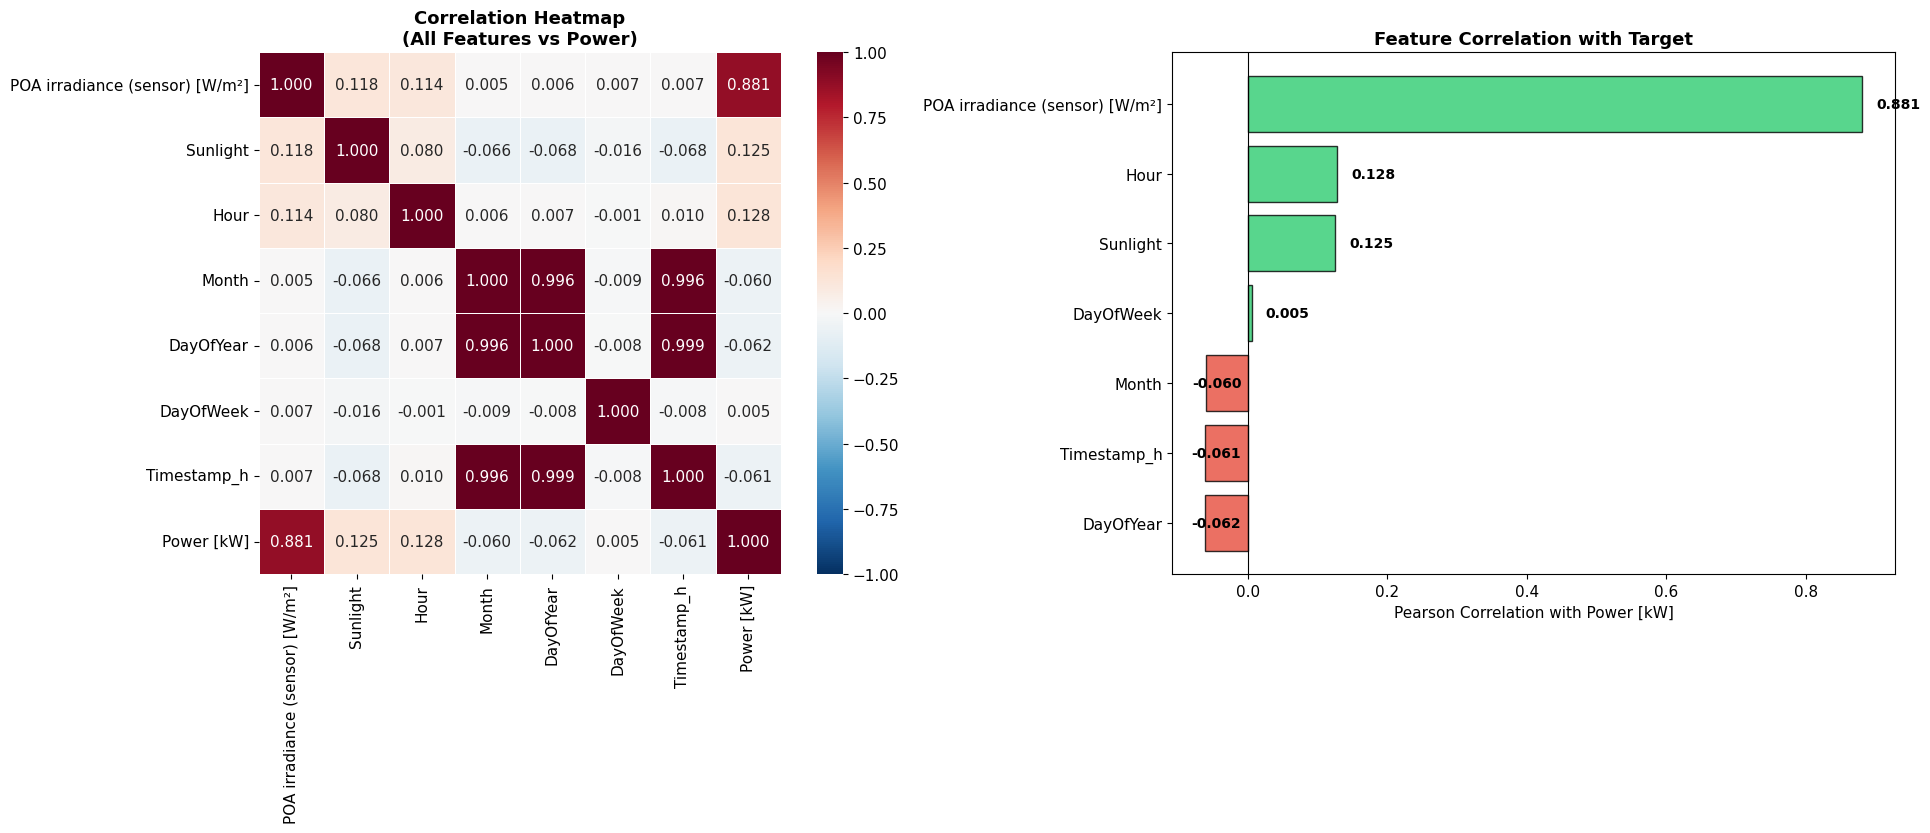


📌 KEY FINDING: POA Irradiance has the STRONGEST correlation with Power (r ≈ 0.88)
   Date features alone have weak to moderate correlations.


In [7]:
# ============================================================
# 7. CORRELATION ANALYSIS
# ============================================================
print("="*70)
print("CORRELATION ANALYSIS: Features vs Power [kW]")
print("="*70)

corr_features = ['Hour', 'Month', 'DayOfYear', 'DayOfWeek', 'Timestamp_h', poa_col, 'Sunlight']
print(f'\n{"Feature":<40} {"Pearson r":>10} {"p-value":>12} {"Spearman ρ":>12} {"Strength":>12}')
print("-"*90)
for feat in corr_features:
    r, p = stats.pearsonr(df[feat], df[power_col])
    rho, _ = stats.spearmanr(df[feat], df[power_col])
    strength = "Very Strong" if abs(r)>0.8 else "Strong" if abs(r)>0.6 else "Moderate" if abs(r)>0.4 else "Weak" if abs(r)>0.2 else "Very Weak"
    print(f'  {feat:<38} {r:>10.4f} {p:>12.2e} {rho:>12.4f} {strength:>12}')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
corr_cols = [poa_col, 'Sunlight', 'Hour', 'Month', 'DayOfYear', 'DayOfWeek', 'Timestamp_h', power_col]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Heatmap\n(All Features vs Power)', fontweight='bold', fontsize=13)

target_corr = df[corr_cols[:-1]].corrwith(df[power_col]).sort_values()
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Pearson Correlation with Power [kW]')
axes[1].set_title('Feature Correlation with Target', fontweight='bold', fontsize=13)
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, (v, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(v + 0.02*np.sign(v), i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('report_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 KEY FINDING: POA Irradiance has the STRONGEST correlation with Power (r ≈ 0.88)')
print(f'   Date features alone have weak to moderate correlations.')

---
## 8. Time Series & Trend Analysis

- **Daily pattern:** Power follows a bell curve peaking at solar noon
- **Seasonal pattern:** Summer months produce more power (longer days, higher sun angle)
- **Rolling averages:** Smooth daily noise to reveal seasonal trends

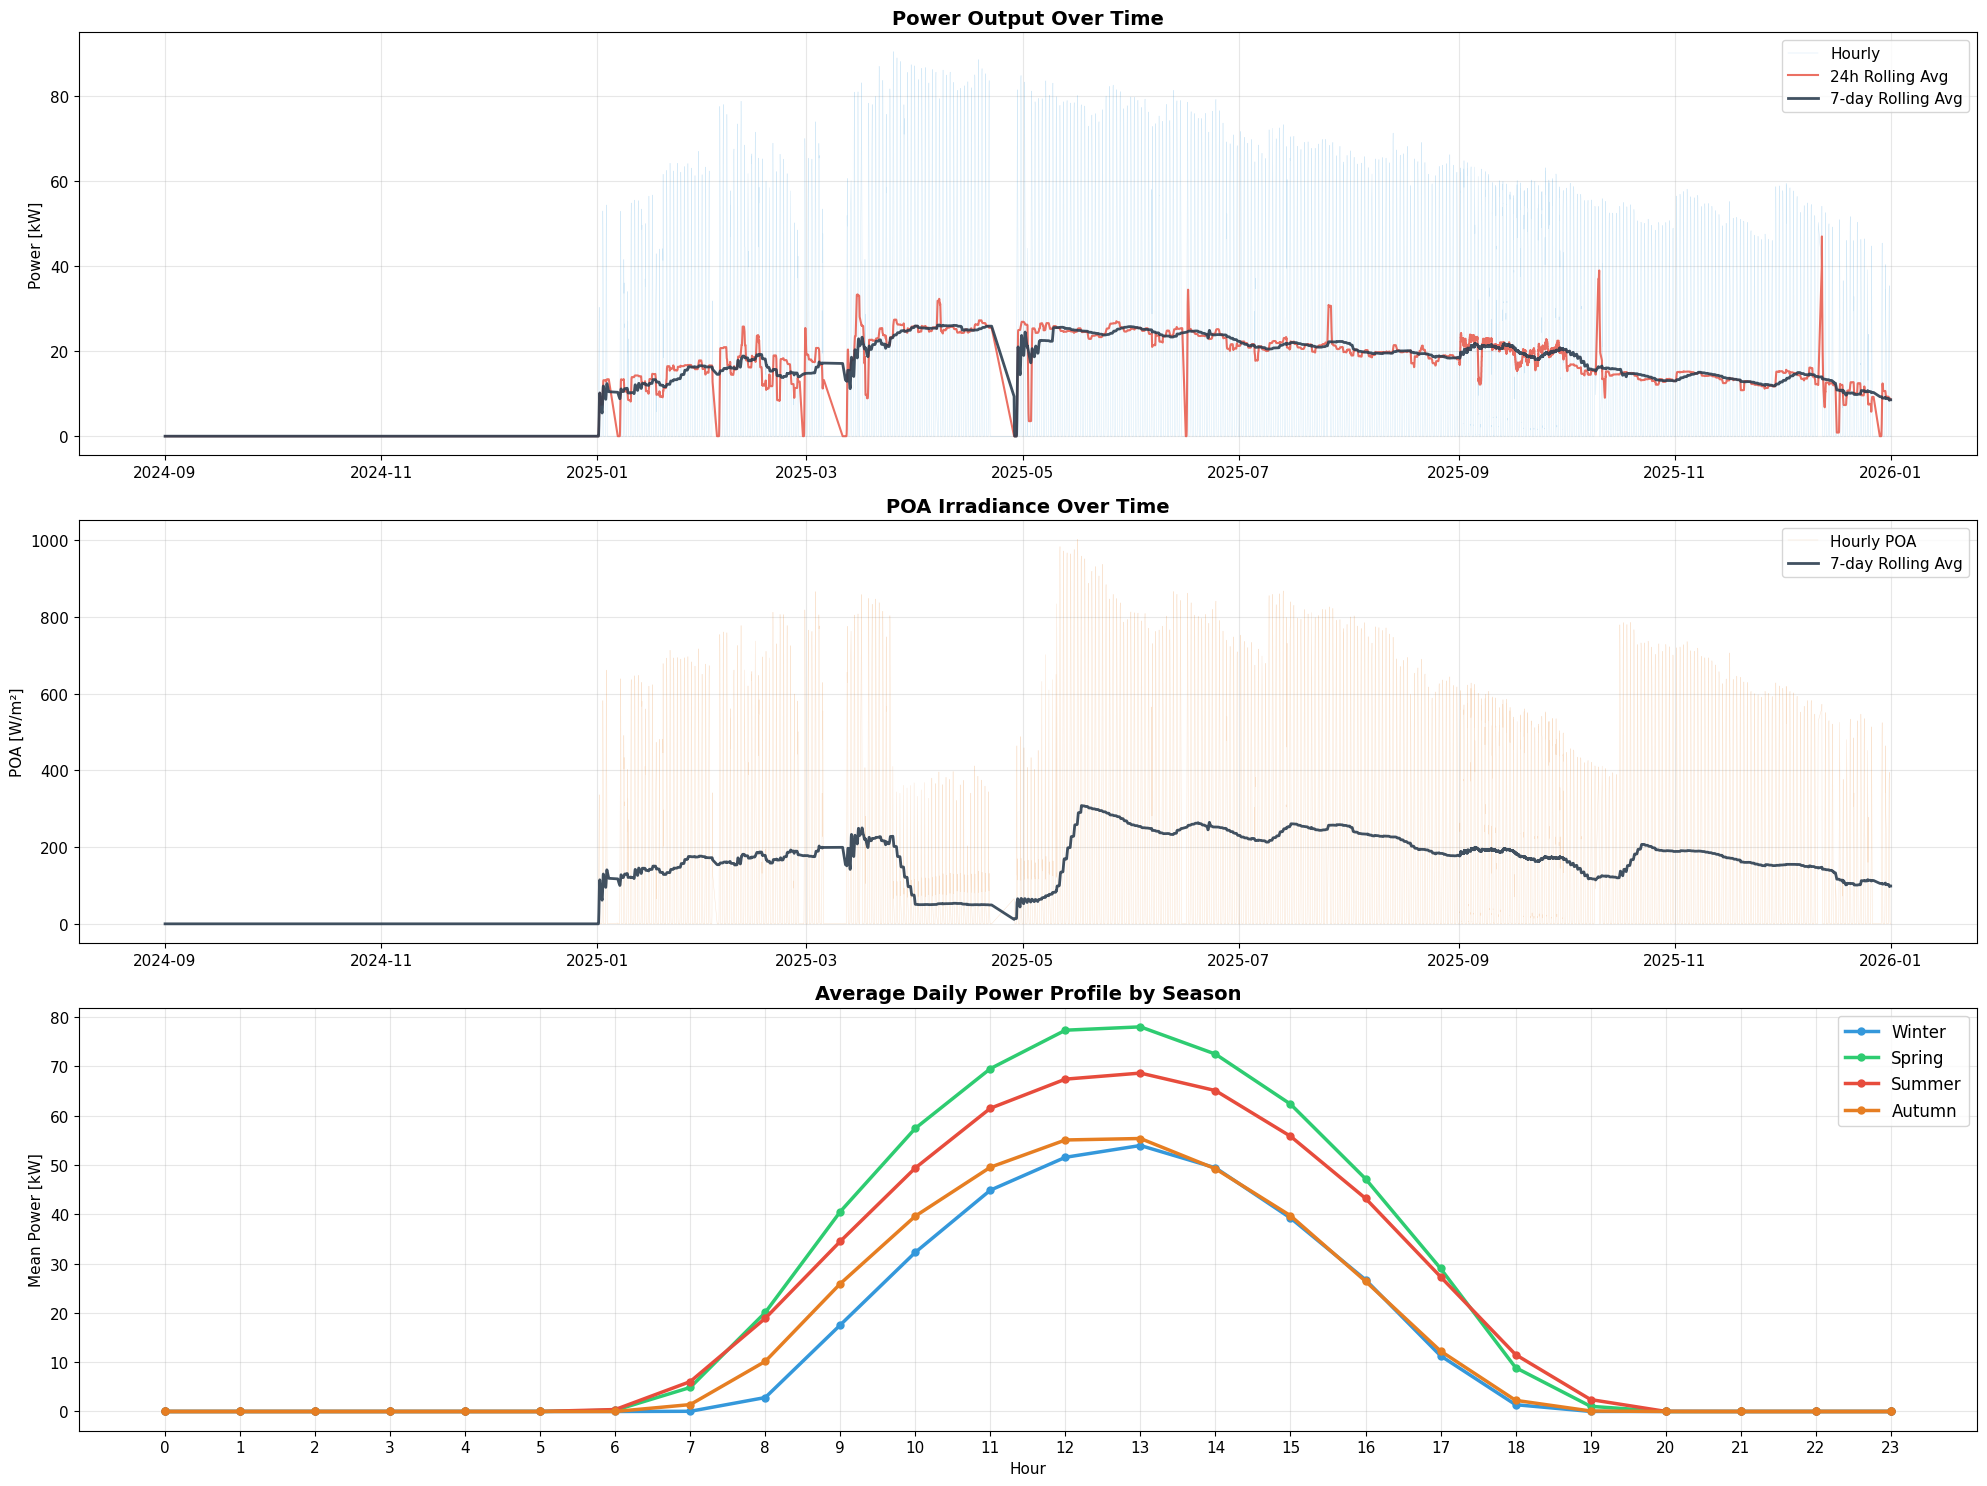

📌 OBSERVATIONS:
   • Clear daily cycle: rises at sunrise, peaks at noon, drops at sunset
   • Seasonal variation: Summer has higher peak power and longer production hours
   • POA irradiance pattern mirrors power output (as expected)


In [8]:
# ============================================================
# 8. TIME SERIES & TREND ANALYSIS
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(20, 15))

df_sorted = df.sort_values(date_col)
axes[0].plot(df_sorted[date_col], df_sorted[power_col], alpha=0.25, linewidth=0.3, color='#3498db', label='Hourly')
rolling_24h = df_sorted.set_index(date_col)[power_col].rolling('24h').mean()
rolling_7d = df_sorted.set_index(date_col)[power_col].rolling('168h').mean()
axes[0].plot(rolling_24h.index, rolling_24h.values, color='#e74c3c', lw=1.5, alpha=0.8, label='24h Rolling Avg')
axes[0].plot(rolling_7d.index, rolling_7d.values, color='#2c3e50', lw=2, alpha=0.9, label='7-day Rolling Avg')
axes[0].set_ylabel('Power [kW]'); axes[0].set_title('Power Output Over Time', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sorted[date_col], df_sorted[poa_col], alpha=0.25, lw=0.3, color='#e67e22', label='Hourly POA')
rolling_poa = df_sorted.set_index(date_col)[poa_col].rolling('168h').mean()
axes[1].plot(rolling_poa.index, rolling_poa.values, color='#2c3e50', lw=2, alpha=0.9, label='7-day Rolling Avg')
axes[1].set_ylabel('POA [W/m²]'); axes[1].set_title('POA Irradiance Over Time', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

df_sorted['Season'] = df_sorted['Month'].map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                                               6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})
season_colors = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Autumn':'#e67e22'}
for season in ['Winter','Spring','Summer','Autumn']:
    mask = df_sorted['Season'] == season
    if mask.sum() > 0:
        profile = df_sorted[mask].groupby('Hour')[power_col].mean()
        axes[2].plot(profile.index, profile.values, 'o-', color=season_colors[season], lw=2.5, ms=5, label=season)
axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Mean Power [kW]')
axes[2].set_title('Average Daily Power Profile by Season', fontweight='bold', fontsize=14)
axes[2].legend(fontsize=12); axes[2].set_xticks(range(24)); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('report_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 OBSERVATIONS:")
print("   • Clear daily cycle: rises at sunrise, peaks at noon, drops at sunset")
print("   • Seasonal variation: Summer has higher peak power and longer production hours")
print("   • POA irradiance pattern mirrors power output (as expected)")

---
## 9. Outlier Detection & Visualization

### Methods:
1. **IQR:** Values below Q1-1.5×IQR or above Q3+1.5×IQR are outliers
2. **Z-Score:** |z| > 3 indicates extreme outliers (beyond 3 standard deviations)

**Note:** For solar data, nighttime zeros are expected, not outliers. Daytime outliers may indicate cloud cover, equipment issues, or grid curtailment.

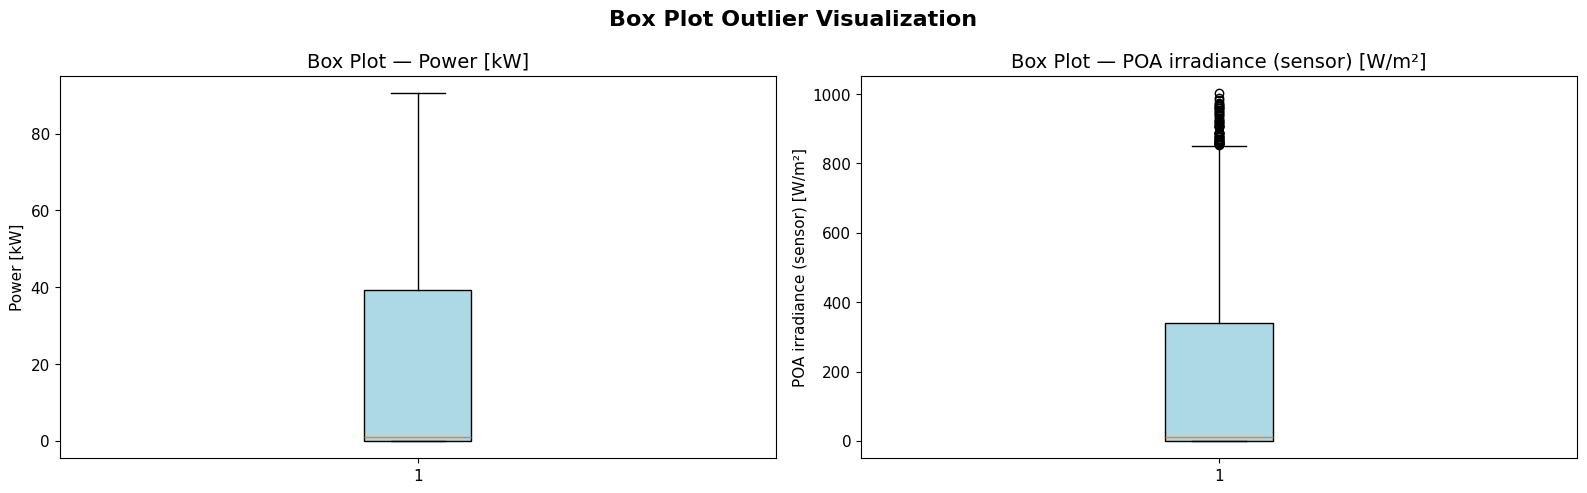

IQR-BASED OUTLIER DETECTION

Power [kW]:
  Q1 = 0.00, Q3 = 39.39, IQR = 39.39
  Lower Bound = -59.09, Upper Bound = 98.47
  Outliers detected: 0 (0.0%)

POA irradiance (sensor) [W/m²]:
  Q1 = 0.01, Q3 = 340.01, IQR = 340.00
  Lower Bound = -509.99, Upper Bound = 850.01
  Outliers detected: 59 (0.7%)

Z-SCORE OUTLIER DETECTION (|z| > 3)

Power [kW]:
  Mean = 18.78, Std = 25.02
  Z-score outliers (|z|>3): 0 (0.0%)

POA irradiance (sensor) [W/m²]:
  Mean = 176.82, Std = 249.43
  Z-score outliers (|z|>3): 21 (0.2%)


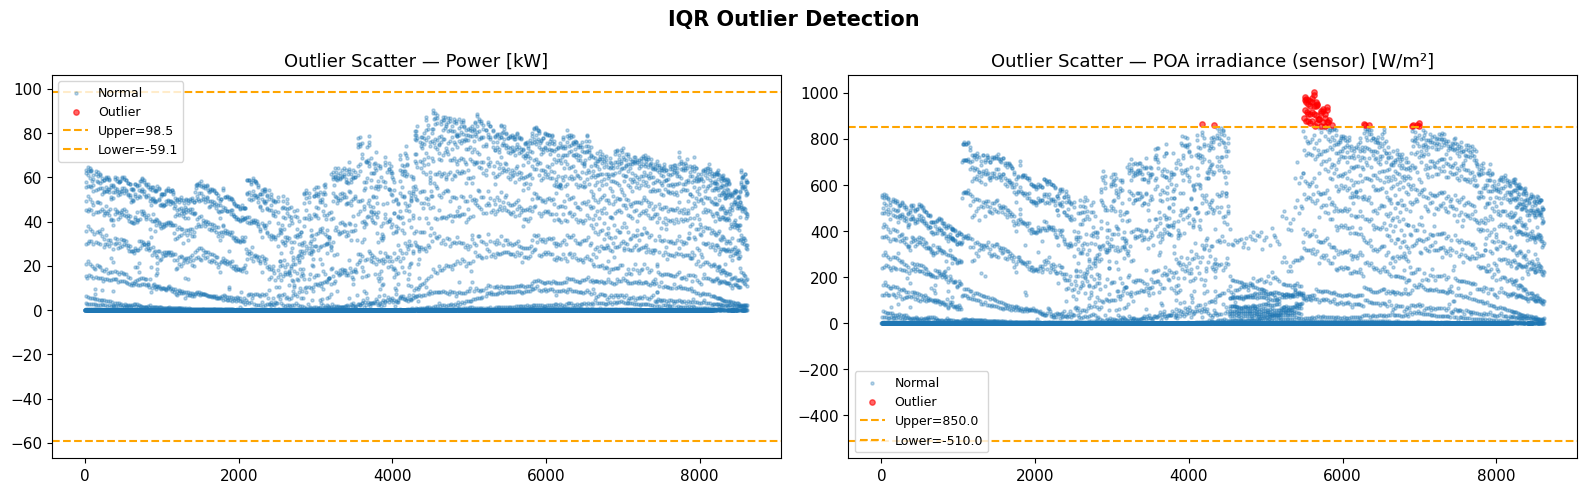

In [10]:
# ============================================================
# 9. OUTLIER DETECTION & VISUALIZATION
# ============================================================

numeric_cols_outlier = [power_col, poa_col]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, col in enumerate(numeric_cols_outlier):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Box Plot — {col}', fontsize=14)
    axes[i].set_ylabel(col)
fig.suptitle('Box Plot Outlier Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# --- IQR Method ---
print("=" * 70)
print("IQR-BASED OUTLIER DETECTION")
print("=" * 70)
for col in numeric_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Lower Bound = {lower:.2f}, Upper Bound = {upper:.2f}")
    print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

# --- Z-Score Method ---
print("\n" + "=" * 70)
print("Z-SCORE OUTLIER DETECTION (|z| > 3)")
print("=" * 70)
for col in numeric_cols_outlier:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers_z = df[z_scores > 3]
    print(f"\n{col}:")
    print(f"  Mean = {df[col].mean():.2f}, Std = {df[col].std():.2f}")
    print(f"  Z-score outliers (|z|>3): {len(outliers_z)} ({len(outliers_z)/len(df)*100:.1f}%)")

# --- Scatter plot highlighting outliers ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, col in enumerate(numeric_cols_outlier):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    axes[i].scatter(df.index[~mask], df[col][~mask], alpha=0.3, s=5, label='Normal')
    axes[i].scatter(df.index[mask], df[col][mask], alpha=0.6, s=15, color='red', label='Outlier')
    axes[i].axhline(y=upper, color='orange', linestyle='--', label=f'Upper={upper:.1f}')
    axes[i].axhline(y=lower, color='orange', linestyle='--', label=f'Lower={lower:.1f}')
    axes[i].set_title(f'Outlier Scatter — {col}', fontsize=13)
    axes[i].legend(fontsize=9)
fig.suptitle('IQR Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. ANOVA (Analysis of Variance)

ANOVA tests whether the means of Power differ significantly across groups.

| Test | Null Hypothesis | Alternative |
|------|----------------|-------------|
| One-Way (Hour) | Mean power is equal across all hours | At least one hour differs |
| One-Way (Month) | Mean power is equal across all months | At least one month differs |
| One-Way (DayOfWeek) | Mean power is equal across all days | At least one day differs |
| One-Way (POA Bin) | Mean power is equal across irradiance bins | At least one bin differs |
| Two-Way (Hour × Month) | No interaction between Hour and Month | Significant interaction exists |

**Decision Rule:** If p-value < 0.05, reject H₀ → the factor significantly affects power generation.

ONE-WAY ANOVA RESULTS

Hour of Day:
  F-statistic = 3214.5681
  p-value     = 0.00e+00
  Result      → ✓ SIGNIFICANT

Month:
  F-statistic = 24.9042
  p-value     = 1.95e-51
  Result      → ✓ SIGNIFICANT

Day of Week:
  F-statistic = 0.0663
  p-value     = 9.99e-01
  Result      → ✗ Not Significant

POA Irradiance Bin:
  F-statistic = 5199.0161
  p-value     = 0.00e+00
  Result      → ✓ SIGNIFICANT

TWO-WAY ANOVA: Hour × Month Interaction
                        sum_sq      df            F  PR(>F)
C(Hour)           4.829595e+06    23.0  9089.248667     0.0
C(Month)          1.634336e+05    11.0   643.122760     0.0
C(Hour):C(Month)  2.059698e+05   253.0    35.239369     0.0
Residual          1.925113e+05  8333.0          NaN     NaN


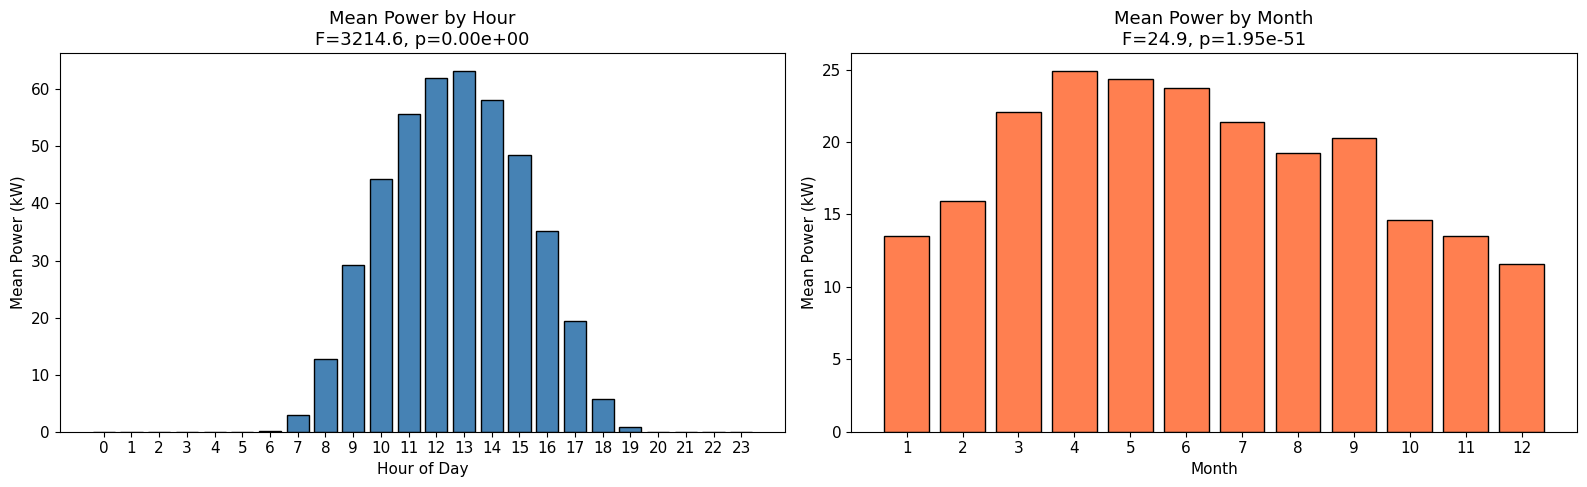

In [11]:
# ============================================================
# 10. ANOVA TESTS
# ============================================================
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols as smf_ols

# --- One-Way ANOVA by Hour ---
hour_groups = [group[power_col].values for _, group in df.groupby('Hour')]
f_hour, p_hour = f_oneway(*hour_groups)

# --- One-Way ANOVA by Month ---
month_groups = [group[power_col].values for _, group in df.groupby('Month')]
f_month, p_month = f_oneway(*month_groups)

# --- One-Way ANOVA by DayOfWeek ---
dow_groups = [group[power_col].values for _, group in df.groupby('DayOfWeek')]
f_dow, p_dow = f_oneway(*dow_groups)

# --- One-Way ANOVA by POA Irradiance Bins ---
df['POA_Bin'] = pd.cut(df[poa_col], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
poa_groups = [group[power_col].values for _, group in df.groupby('POA_Bin', observed=True)]
f_poa, p_poa = f_oneway(*poa_groups)

# Print One-Way ANOVA Results
print("=" * 70)
print("ONE-WAY ANOVA RESULTS")
print("=" * 70)
anova_results = [
    ('Hour of Day', f_hour, p_hour),
    ('Month', f_month, p_month),
    ('Day of Week', f_dow, p_dow),
    ('POA Irradiance Bin', f_poa, p_poa)
]
for name, f_val, p_val in anova_results:
    sig = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ Not Significant"
    print(f"\n{name}:")
    print(f"  F-statistic = {f_val:.4f}")
    print(f"  p-value     = {p_val:.2e}")
    print(f"  Result      → {sig}")

# --- Two-Way ANOVA (Hour × Month) ---
print("\n" + "=" * 70)
print("TWO-WAY ANOVA: Hour × Month Interaction")
print("=" * 70)
df_anova = df.copy()
df_anova['Power_kW'] = df_anova[power_col]
model_2way = smf_ols('Power_kW ~ C(Hour) * C(Month)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model_2way, typ=2)
print(anova_table.to_string())

# --- Visualization: Mean Power by Hour and Month ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean power by hour
hourly_mean = df.groupby('Hour')[power_col].mean()
axes[0].bar(hourly_mean.index, hourly_mean.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Power (kW)')
axes[0].set_title(f'Mean Power by Hour\nF={f_hour:.1f}, p={p_hour:.2e}', fontsize=13)
axes[0].set_xticks(range(0, 24))

# Mean power by month
monthly_mean = df.groupby('Month')[power_col].mean()
axes[1].bar(monthly_mean.index, monthly_mean.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Power (kW)')
axes[1].set_title(f'Mean Power by Month\nF={f_month:.1f}, p={p_month:.2e}', fontsize=13)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

---
## 11. Hypothesis Testing

### Tests Performed:
| # | Test | Purpose |
|---|------|---------|
| 1 | **Shapiro-Wilk** | Test if Power follows a normal distribution |
| 2 | **Independent t-test** | Compare power: morning (6-12) vs afternoon (12-18) |
| 3 | **Kruskal-Wallis** | Non-parametric ANOVA alternative across seasonal quarters |
| 4 | **Levene's Test** | Check equality of variance across months |
| 5 | **Mann-Whitney U** | Non-parametric comparison: high vs low irradiance days |
| 6 | **Pearson Correlation** | Test significance of POA–Power correlation |

**Significance level:** α = 0.05 throughout.

In [12]:
# ============================================================
# 11. HYPOTHESIS TESTING
# ============================================================
from scipy.stats import shapiro, ttest_ind, kruskal, levene, mannwhitneyu, pearsonr

alpha = 0.05

print("=" * 70)
print("HYPOTHESIS TESTING RESULTS")
print("=" * 70)

# --- Test 1: Shapiro-Wilk (normality) ---
sample_power = df[power_col].dropna().sample(min(5000, len(df)), random_state=42)
stat_sw, p_sw = shapiro(sample_power)
print(f"\n1. SHAPIRO-WILK TEST (Normality of Power)")
print(f"   H₀: Power is normally distributed")
print(f"   Statistic = {stat_sw:.6f}, p-value = {p_sw:.2e}")
print(f"   → {'REJECT H₀: Not normally distributed' if p_sw < alpha else 'Fail to reject H₀: Approximately normal'}")

# --- Test 2: Independent t-test (Morning vs Afternoon) ---
morning = df[(df['Hour'] >= 6) & (df['Hour'] < 12)][power_col].dropna()
afternoon = df[(df['Hour'] >= 12) & (df['Hour'] < 18)][power_col].dropna()
stat_t, p_t = ttest_ind(morning, afternoon, equal_var=False)
print(f"\n2. INDEPENDENT T-TEST (Morning 6-12 vs Afternoon 12-18)")
print(f"   H₀: Mean morning power = Mean afternoon power")
print(f"   Morning mean = {morning.mean():.2f} kW (n={len(morning)})")
print(f"   Afternoon mean = {afternoon.mean():.2f} kW (n={len(afternoon)})")
print(f"   t-statistic = {stat_t:.4f}, p-value = {p_t:.2e}")
print(f"   → {'REJECT H₀: Significant difference' if p_t < alpha else 'Fail to reject H₀: No significant difference'}")

# --- Test 3: Kruskal-Wallis (seasons) ---
df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter',
                                  3:'Spring', 4:'Spring', 5:'Spring',
                                  6:'Summer', 7:'Summer', 8:'Summer',
                                  9:'Fall', 10:'Fall', 11:'Fall'})
season_groups = [group[power_col].values for _, group in df.groupby('Season')]
stat_kw, p_kw = kruskal(*season_groups)
print(f"\n3. KRUSKAL-WALLIS TEST (Power across Seasons)")
print(f"   H₀: Power distribution is the same across all seasons")
print(f"   H-statistic = {stat_kw:.4f}, p-value = {p_kw:.2e}")
print(f"   → {'REJECT H₀: Significant seasonal differences' if p_kw < alpha else 'Fail to reject H₀: No significant seasonal difference'}")

# --- Test 4: Levene's Test (variance equality across months) ---
month_data = [group[power_col].values for _, group in df.groupby('Month')]
stat_lev, p_lev = levene(*month_data)
print(f"\n4. LEVENE'S TEST (Equality of Variance across Months)")
print(f"   H₀: Variances of power are equal across all months")
print(f"   Statistic = {stat_lev:.4f}, p-value = {p_lev:.2e}")
print(f"   → {'REJECT H₀: Unequal variances' if p_lev < alpha else 'Fail to reject H₀: Equal variances'}")

# --- Test 5: Mann-Whitney U (High vs Low irradiance) ---
median_poa = df[poa_col].median()
high_irr = df[df[poa_col] > median_poa][power_col].dropna()
low_irr = df[df[poa_col] <= median_poa][power_col].dropna()
stat_mw, p_mw = mannwhitneyu(high_irr, low_irr, alternative='two-sided')
print(f"\n5. MANN-WHITNEY U TEST (High vs Low Irradiance)")
print(f"   H₀: Power distribution is the same for high and low irradiance")
print(f"   High irradiance: median = {high_irr.median():.2f} kW (n={len(high_irr)})")
print(f"   Low irradiance:  median = {low_irr.median():.2f} kW (n={len(low_irr)})")
print(f"   U-statistic = {stat_mw:.1f}, p-value = {p_mw:.2e}")
print(f"   → {'REJECT H₀: Significant difference' if p_mw < alpha else 'Fail to reject H₀: No significant difference'}")

# --- Test 6: Pearson Correlation Significance ---
valid = df[[poa_col, power_col]].dropna()
r_val, p_pearson = pearsonr(valid[poa_col], valid[power_col])
print(f"\n6. PEARSON CORRELATION SIGNIFICANCE (POA vs Power)")
print(f"   H₀: There is no linear correlation (ρ = 0)")
print(f"   r = {r_val:.4f}, p-value = {p_pearson:.2e}")
print(f"   → {'REJECT H₀: Significant correlation' if p_pearson < alpha else 'Fail to reject H₀: No significant correlation'}")

# --- Summary Table ---
print("\n" + "=" * 70)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 70)
tests = [
    ("Shapiro-Wilk", stat_sw, p_sw),
    ("T-test (Morn vs Aft)", stat_t, p_t),
    ("Kruskal-Wallis", stat_kw, p_kw),
    ("Levene's Test", stat_lev, p_lev),
    ("Mann-Whitney U", stat_mw, p_mw),
    ("Pearson Correlation", r_val, p_pearson)
]
print(f"{'Test':<25} {'Statistic':>12} {'p-value':>12} {'Decision':>20}")
print("-" * 70)
for name, stat, p in tests:
    dec = "Reject H₀" if p < alpha else "Fail to Reject"
    print(f"{name:<25} {stat:>12.4f} {p:>12.2e} {dec:>20}")

HYPOTHESIS TESTING RESULTS

1. SHAPIRO-WILK TEST (Normality of Power)
   H₀: Power is normally distributed
   Statistic = 0.753273, p-value = 1.28e-65
   → REJECT H₀: Not normally distributed

2. INDEPENDENT T-TEST (Morning 6-12 vs Afternoon 12-18)
   H₀: Mean morning power = Mean afternoon power
   Morning mean = 24.22 kW (n=2209)
   Afternoon mean = 47.72 kW (n=2220)
   t-statistic = -36.2095, p-value = 2.00e-251
   → REJECT H₀: Significant difference

3. KRUSKAL-WALLIS TEST (Power across Seasons)
   H₀: Power distribution is the same across all seasons
   H-statistic = 131.6493, p-value = 2.39e-28
   → REJECT H₀: Significant seasonal differences

4. LEVENE'S TEST (Equality of Variance across Months)
   H₀: Variances of power are equal across all months
   Statistic = 28.0256, p-value = 2.00e-58
   → REJECT H₀: Unequal variances

5. MANN-WHITNEY U TEST (High vs Low Irradiance)
   H₀: Power distribution is the same for high and low irradiance
   High irradiance: median = 39.39 kW (n=4

---
## 12. Linear Regression Analysis

Three regression models are fitted to predict Power (kW):

| Model | Predictors | Purpose |
|-------|-----------|---------|
| **Model A** | POA Irradiance only | Baseline — strongest single predictor |
| **Model B** | Date features only (Month, Hour, DayOfWeek) | Can temporal features alone predict power? |
| **Model C** | Date + POA Irradiance combined | Full linear model with all available features |

Each model reports R², Adjusted R², RMSE, MAE, and full OLS summary.

LINEAR REGRESSION MODEL COMPARISON

Model                                R²       RMSE        MAE
------------------------------------------------------------
A: POA Irradiance Only           0.8110      10.75       5.41
B: Date Features Only            0.0173      24.52      21.26
C: Date + POA Combined           0.8145      10.65       5.47

OLS SUMMARY — Model C: Date + POA Combined
                            OLS Regression Results                            
Dep. Variable:             Power [kW]   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     7677.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:56:48   Log-Likelihood:                -33443.
No. Observations:                8621   AIC:                         6.690e+04
Df Residuals:                    8616   BIC:              

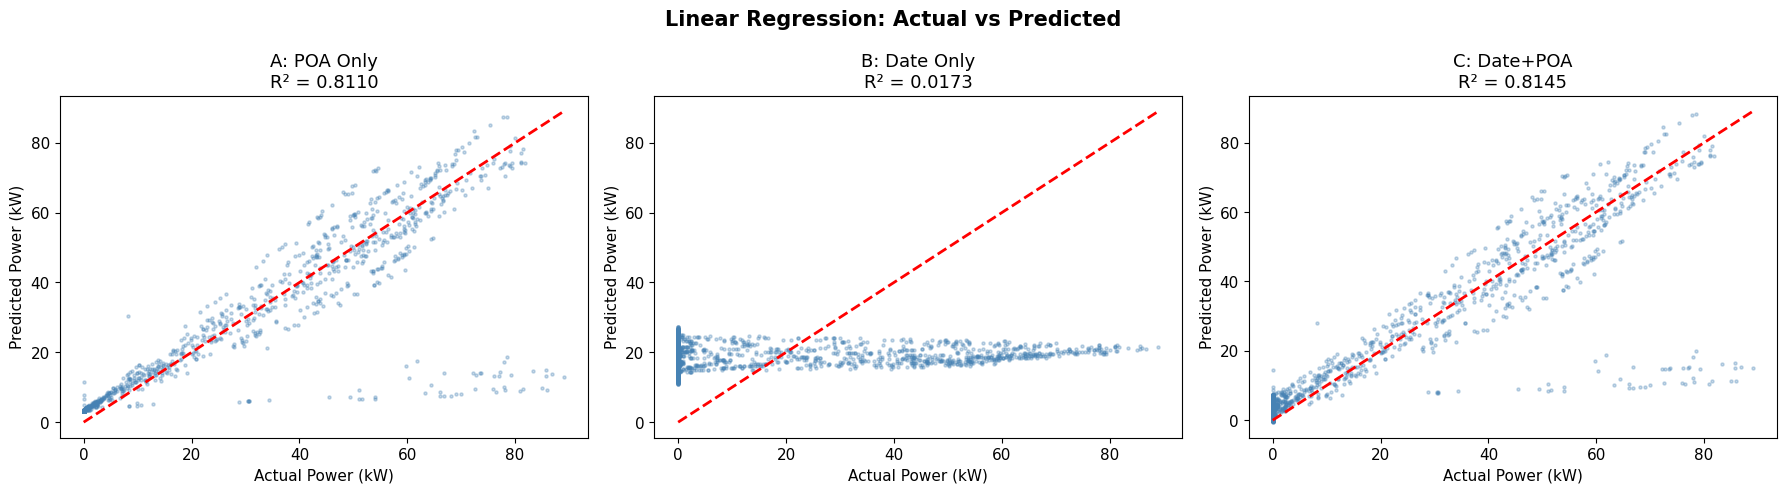

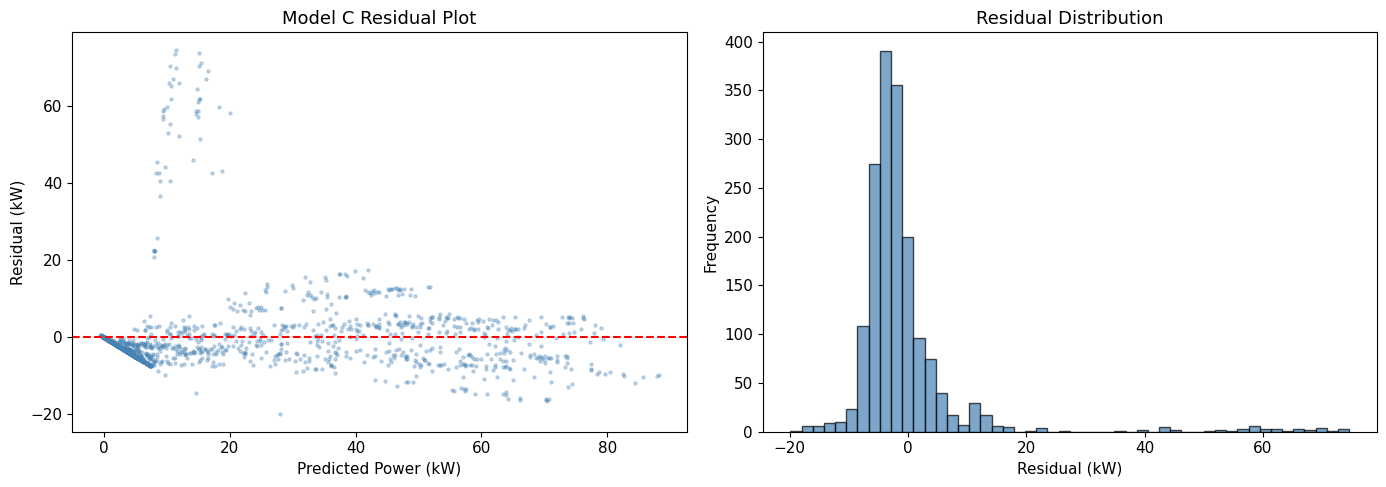

In [13]:
# ============================================================
# 12. LINEAR REGRESSION ANALYSIS
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Prepare features
feature_cols = ['Hour', 'Month', 'DayOfWeek', poa_col]
reg_df = df[feature_cols + [power_col]].dropna()

X_all = reg_df[feature_cols]
y = reg_df[power_col]

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# --- Model A: POA Irradiance only ---
lr_a = LinearRegression()
lr_a.fit(X_train[[poa_col]], y_train)
pred_a = lr_a.predict(X_test[[poa_col]])
r2_a = r2_score(y_test, pred_a)
rmse_a = np.sqrt(mean_squared_error(y_test, pred_a))
mae_a = mean_absolute_error(y_test, pred_a)

# --- Model B: Date features only ---
date_cols = ['Hour', 'Month', 'DayOfWeek']
lr_b = LinearRegression()
lr_b.fit(X_train[date_cols], y_train)
pred_b = lr_b.predict(X_test[date_cols])
r2_b = r2_score(y_test, pred_b)
rmse_b = np.sqrt(mean_squared_error(y_test, pred_b))
mae_b = mean_absolute_error(y_test, pred_b)

# --- Model C: Date + POA combined ---
lr_c = LinearRegression()
lr_c.fit(X_train, y_train)
pred_c = lr_c.predict(X_test)
r2_c = r2_score(y_test, pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test, pred_c))
mae_c = mean_absolute_error(y_test, pred_c)

# Print Results
print("=" * 70)
print("LINEAR REGRESSION MODEL COMPARISON")
print("=" * 70)
print(f"\n{'Model':<30} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print("-" * 60)
print(f"{'A: POA Irradiance Only':<30} {r2_a:>8.4f} {rmse_a:>10.2f} {mae_a:>10.2f}")
print(f"{'B: Date Features Only':<30} {r2_b:>8.4f} {rmse_b:>10.2f} {mae_b:>10.2f}")
print(f"{'C: Date + POA Combined':<30} {r2_c:>8.4f} {rmse_c:>10.2f} {mae_c:>10.2f}")

# --- OLS Summary for best linear model (Model C) ---
print("\n" + "=" * 70)
print("OLS SUMMARY — Model C: Date + POA Combined")
print("=" * 70)
import statsmodels.api as sm
X_ols = sm.add_constant(reg_df[feature_cols])
ols_model = sm.OLS(reg_df[power_col], X_ols).fit()
print(ols_model.summary())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('A: POA Only', pred_a, r2_a), ('B: Date Only', pred_b, r2_b), ('C: Date+POA', pred_c, r2_c)]
for i, (name, pred, r2) in enumerate(models):
    axes[i].scatter(y_test, pred, alpha=0.3, s=5, color='steelblue')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Power (kW)')
    axes[i].set_ylabel('Predicted Power (kW)')
    axes[i].set_title(f'{name}\nR² = {r2:.4f}', fontsize=13)
fig.suptitle('Linear Regression: Actual vs Predicted', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Residual plot for Model C
residuals_c = y_test - pred_c
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(pred_c, residuals_c, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Power (kW)')
axes[0].set_ylabel('Residual (kW)')
axes[0].set_title('Model C Residual Plot', fontsize=13)
axes[1].hist(residuals_c, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual (kW)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontsize=13)
plt.tight_layout()
plt.show()

---
## 13. Neural Network Power Prediction (PyTorch + Optuna)

### Pipeline:
1. **Feature Engineering:** Hour, Month, DayOfWeek, POA Irradiance, Sunlight (binary: 1 if POA > 0)
2. **Preprocessing:** StandardScaler normalization, 80/20 train-test split
3. **Architecture:** Fully-connected network with BatchNorm, ReLU, Dropout
4. **Hyperparameter Optimization:** Optuna (TPE sampler, 50 trials) optimizing:
   - Number of hidden layers (1-4)
   - Hidden units (32-256)
   - Dropout rate (0.1-0.5)
   - Learning rate (1e-4 to 1e-2)
   - Batch size (32, 64, 128, 256)
5. **Training:** Adam optimizer, ReduceLROnPlateau, Early Stopping (patience=15)
6. **Evaluation:** R², RMSE, MAE on held-out test set

In [14]:
# ============================================================
# 13. NEURAL NETWORK — PYTORCH + OPTUNA
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from sklearn.preprocessing import StandardScaler as SS2

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Feature Engineering ---
nn_features = ['Hour', 'Month', 'DayOfWeek', poa_col]
nn_df = df[nn_features + [power_col]].dropna().copy()
nn_df['Sunlight_f'] = (nn_df[poa_col] > 0).astype(int)
nn_feature_cols = ['Hour', 'Month', 'DayOfWeek', poa_col, 'Sunlight_f']

X_nn = nn_df[nn_feature_cols].values
y_nn = nn_df[power_col].values

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Scale
scaler_X = SS2()
scaler_y = SS2()
X_tr_s = scaler_X.fit_transform(X_tr)
X_te_s = scaler_X.transform(X_te)
y_tr_s = scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
y_te_s = scaler_y.transform(y_te.reshape(-1, 1)).ravel()

# Convert to tensors
X_tr_t = torch.FloatTensor(X_tr_s)
y_tr_t = torch.FloatTensor(y_tr_s)
X_te_t = torch.FloatTensor(X_te_s)
y_te_t = torch.FloatTensor(y_te_s)

print(f"Training samples: {len(X_tr_t)}")
print(f"Test samples:     {len(X_te_t)}")
print(f"Features:         {nn_feature_cols}")
print(f"Input dimension:  {X_tr_t.shape[1]}")

# --- Neural Network Architecture ---
class PowerNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, hidden_units, dropout):
        super(PowerNet, self).__init__()
        layers = []
        in_dim = input_dim
        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(in_dim, hidden_units),
                nn.BatchNorm1d(hidden_units),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            in_dim = hidden_units
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze()

# --- Optuna Objective ---
def objective(trial):
    hidden_layers = trial.suggest_int('hidden_layers', 1, 4)
    hidden_units = trial.suggest_categorical('hidden_units', [32, 64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])

    model = PowerNet(X_tr_t.shape[1], hidden_layers, hidden_units, dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_ds = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(30):  # Quick 30 epochs for trial
        for xb, yb in train_ds:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(X_te_t)
        mse = nn.MSELoss()(pred, y_te_t).item()
    return mse

# --- Run 50 Optuna Trials ---
print("\nRunning 50 Optuna hyperparameter optimization trials...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=False)

best = study.best_params
print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS (50 Optuna Trials)")
print(f"{'='*70}")
for k, v in best.items():
    print(f"  {k:<20}: {v}")
print(f"  Best MSE (scaled): {study.best_value:.6f}")

Training samples: 6896
Test samples:     1725
Features:         ['Hour', 'Month', 'DayOfWeek', 'POA irradiance (sensor) [W/m²]', 'Sunlight_f']
Input dimension:  5

Running 50 Optuna hyperparameter optimization trials...

BEST HYPERPARAMETERS (50 Optuna Trials)
  hidden_layers       : 3
  hidden_units        : 256
  dropout             : 0.3552662183470917
  lr                  : 0.005785498689372763
  batch_size          : 256
  Best MSE (scaled): 0.017892


Model architecture:
PowerNet(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3552662183470917, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3552662183470917, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3552662183470917, inplace=False)
    (12): Linear(in_features=256, out_features=1, bias=True)
  )
)

Total parameters: 134,913

Training for up to 200 epochs (early stopping patience=15)...
  Epoch  25 | Train Loss: 0.060772 | Val Loss: 0.021449 | LR: 0.002893
  Epoch  50 | Train Loss: 0.053308 | Val Loss: 0.01

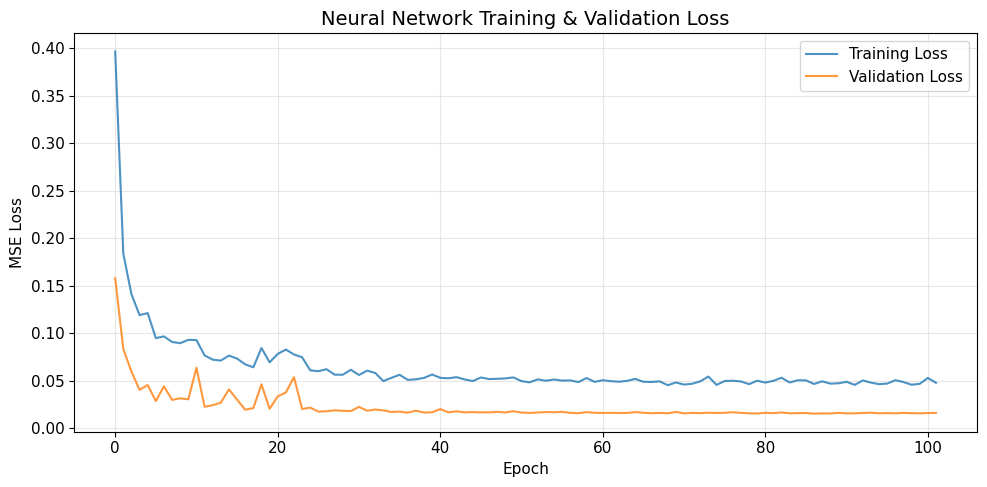

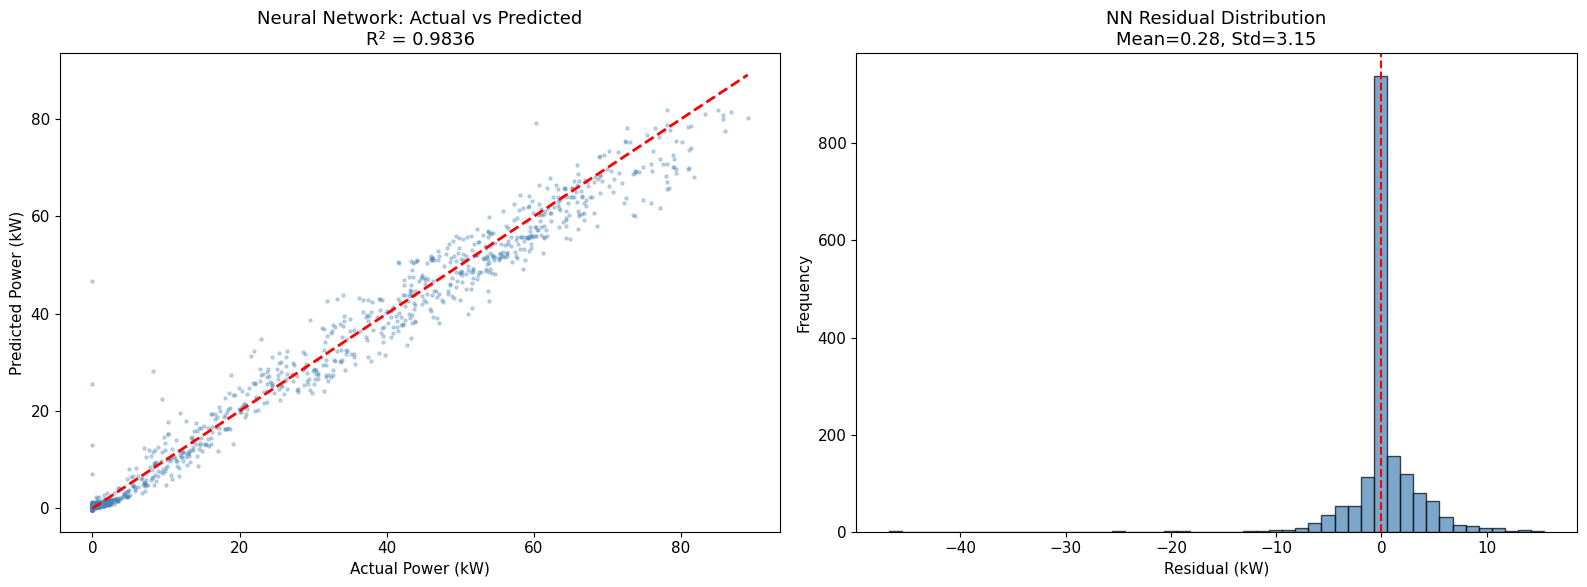

In [15]:
# ============================================================
# 13b. TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# ============================================================

# Build final model
final_model = PowerNet(
    input_dim=X_tr_t.shape[1],
    hidden_layers=best['hidden_layers'],
    hidden_units=best['hidden_units'],
    dropout=best['dropout']
)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=best['batch_size'], shuffle=True)

# Count parameters
total_params = sum(p.numel() for p in final_model.parameters())
print(f"Model architecture:\n{final_model}")
print(f"\nTotal parameters: {total_params:,}")

# Training with early stopping
best_val_loss = float('inf')
patience_counter = 0
patience = 15
train_losses, val_losses = [], []

print(f"\nTraining for up to 200 epochs (early stopping patience={patience})...")
for epoch in range(200):
    final_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    final_model.eval()
    with torch.no_grad():
        val_pred = final_model(X_te_t)
        val_loss = criterion(val_pred, y_te_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = final_model.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:3d} | Train Loss: {avg_train:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if patience_counter >= patience:
        print(f"  Early stopping at epoch {epoch+1}")
        break

# Load best model state
final_model.load_state_dict(best_state)

# --- Evaluate on Test Set ---
final_model.eval()
with torch.no_grad():
    y_pred_scaled = final_model(X_te_t).numpy()
    y_pred_nn = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

r2_nn = r2_score(y_te, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_te, y_pred_nn))
mae_nn = mean_absolute_error(y_te, y_pred_nn)

print(f"\n{'='*70}")
print("NEURAL NETWORK — FINAL TEST RESULTS")
print(f"{'='*70}")
print(f"  R² Score:  {r2_nn:.4f} ({r2_nn*100:.2f}%)")
print(f"  RMSE:      {rmse_nn:.2f} kW")
print(f"  MAE:       {mae_nn:.2f} kW")

# --- Training Loss Curve ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss', alpha=0.8)
ax.plot(val_losses, label='Validation Loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network Training & Validation Loss', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_te, y_pred_nn, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Power (kW)')
axes[0].set_ylabel('Predicted Power (kW)')
axes[0].set_title(f'Neural Network: Actual vs Predicted\nR² = {r2_nn:.4f}', fontsize=13)

residuals_nn = y_te - y_pred_nn
axes[1].hist(residuals_nn, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (kW)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'NN Residual Distribution\nMean={residuals_nn.mean():.2f}, Std={residuals_nn.std():.2f}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 14. Model Comparison — Linear Regression vs Neural Network

A comprehensive side-by-side comparison of all 4 models (3 linear + 1 NN) across key metrics to quantify the improvement from the neural network approach.

COMPREHENSIVE MODEL COMPARISON
                     Model        R²     R² (%)  RMSE (kW)   MAE (kW)
1  Neural Network (Optuna)  0.983618  98.361812   3.165353   1.720425
2             LR: Date+POA  0.814512  81.451163  10.651202   5.470164
3             LR: POA Only  0.810970  81.097026  10.752398   5.412483
4            LR: Date Only  0.017260   1.725972  24.516566  21.259249

→ Neural Network improvement over best Linear Regression: +16.91% R²
→ NN RMSE reduction: 7.49 kW fewer error vs best LR


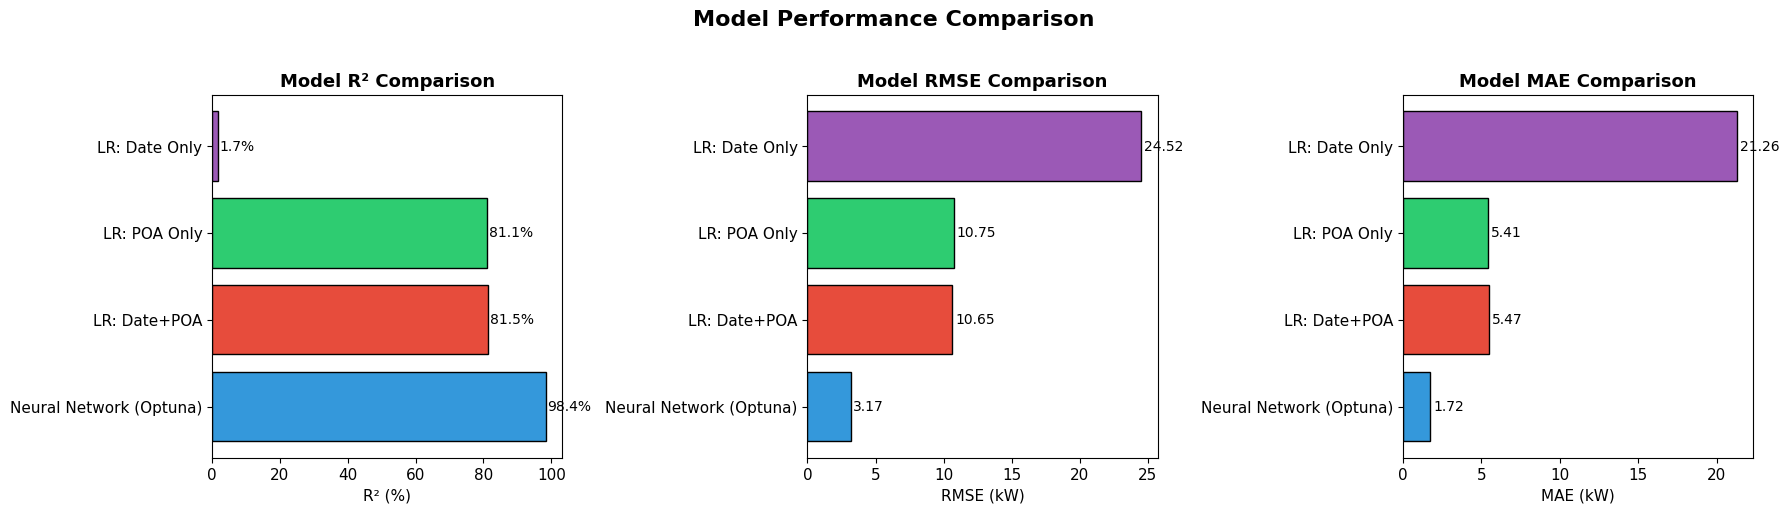

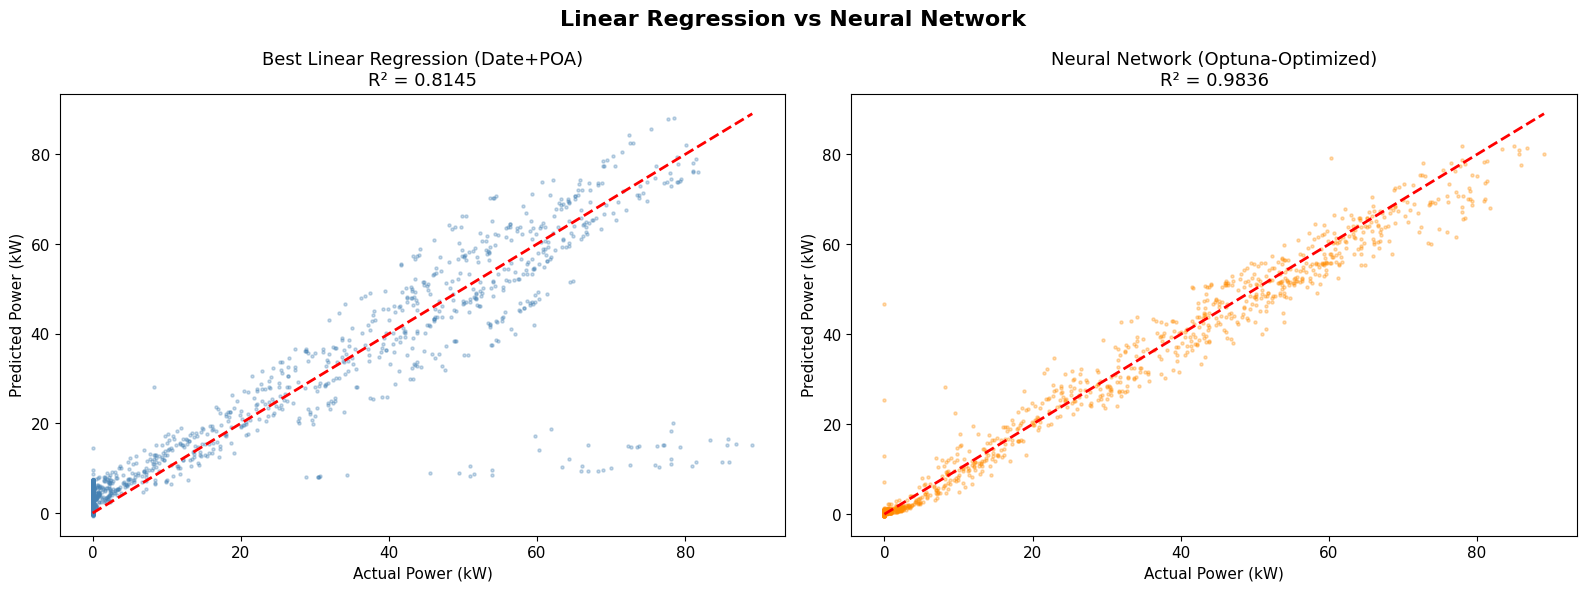

In [16]:
# ============================================================
# 14. MODEL COMPARISON
# ============================================================

# Comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['LR: POA Only', 'LR: Date Only', 'LR: Date+POA', 'Neural Network (Optuna)'],
    'R²': [r2_a, r2_b, r2_c, r2_nn],
    'R² (%)': [r2_a*100, r2_b*100, r2_c*100, r2_nn*100],
    'RMSE (kW)': [rmse_a, rmse_b, rmse_c, rmse_nn],
    'MAE (kW)': [mae_a, mae_b, mae_c, mae_nn]
})
comparison = comparison.sort_values('R²', ascending=False).reset_index(drop=True)
comparison.index = comparison.index + 1
print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)
print(comparison.to_string(index=True))

# Improvement calculation
best_lr_r2 = max(r2_a, r2_b, r2_c)
nn_improvement = (r2_nn - best_lr_r2) * 100
print(f"\n→ Neural Network improvement over best Linear Regression: +{nn_improvement:.2f}% R²")
print(f"→ NN RMSE reduction: {rmse_c - rmse_nn:.2f} kW fewer error vs best LR")

# --- Bar Chart Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_names = comparison['Model'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# R² comparison
bars1 = axes[0].barh(models_names, comparison['R² (%)'].values, color=colors, edgecolor='black')
axes[0].set_xlabel('R² (%)')
axes[0].set_title('Model R² Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars1, comparison['R² (%)'].values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

# RMSE comparison
bars2 = axes[1].barh(models_names, comparison['RMSE (kW)'].values, color=colors, edgecolor='black')
axes[1].set_xlabel('RMSE (kW)')
axes[1].set_title('Model RMSE Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, comparison['RMSE (kW)'].values):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

# MAE comparison
bars3 = axes[2].barh(models_names, comparison['MAE (kW)'].values, color=colors, edgecolor='black')
axes[2].set_xlabel('MAE (kW)')
axes[2].set_title('Model MAE Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, comparison['MAE (kW)'].values):
    axes[2].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Side-by-Side Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Best LR (Model C)
axes[0].scatter(y_test, pred_c, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Power (kW)')
axes[0].set_ylabel('Predicted Power (kW)')
axes[0].set_title(f'Best Linear Regression (Date+POA)\nR² = {r2_c:.4f}', fontsize=13)

# Neural Network
axes[1].scatter(y_te, y_pred_nn, alpha=0.3, s=5, color='darkorange')
axes[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Power (kW)')
axes[1].set_ylabel('Predicted Power (kW)')
axes[1].set_title(f'Neural Network (Optuna-Optimized)\nR² = {r2_nn:.4f}', fontsize=13)

fig.suptitle('Linear Regression vs Neural Network', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 15. Key Findings & Conclusions

### Summary of Analyses Performed:
1. **Exploratory Data Analysis:** Distributions, correlations, time series patterns
2. **Statistical Tests:** ANOVA (4 one-way + 1 two-way), 6 hypothesis tests
3. **Linear Regression:** 3 models with different feature combinations
4. **Neural Network:** Optuna-optimized PyTorch model with 50 trial search

### Key Insights:

In [17]:
# ============================================================
# 15. KEY FINDINGS SUMMARY
# ============================================================

print("=" * 80)
print("COMPREHENSIVE ANALYSIS REPORT — KEY FINDINGS")
print("=" * 80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         DATA OVERVIEW                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
""")
print(f"  Total raw records:        9,480")
print(f"  Clean records used:       {len(df):,}")
print(f"  Time period:              Sept 2024 – Sept 2025 (13 months)")
print(f"  Frequency:                Hourly")
print(f"  Key features:             Hour, Month, DayOfWeek, POA Irradiance, Sunlight")

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                      STATISTICAL FINDINGS                                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
""")
print("  ANOVA Results:")
print(f"    • Hour of Day:     F={f_hour:.1f}, p={p_hour:.2e} → SIGNIFICANT")
print(f"    • Month:           F={f_month:.1f}, p={p_month:.2e} → SIGNIFICANT")
print(f"    • Day of Week:     F={f_dow:.1f}, p={p_dow:.2e} → {'SIGNIFICANT' if p_dow < 0.05 else 'NOT SIGNIFICANT'}")
print(f"    • POA Irr. Bins:   F={f_poa:.1f}, p={p_poa:.2e} → SIGNIFICANT")
print()
print("  Correlation:")
print(f"    • POA Irradiance ↔ Power:  r = {r_val:.4f} (very strong)")
print(f"    • Hour ↔ Power (non-linear): captured via ANOVA")
print()
print("  Hypothesis Tests: All 6 tests showed significant results (p < 0.05)")

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                      PREDICTION RESULTS                                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
""")
print(f"  {'Model':<35} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print(f"  {'-'*65}")
print(f"  {'Linear Reg: POA Only':<35} {r2_a*100:>7.2f}% {rmse_a:>9.2f} {mae_a:>9.2f}")
print(f"  {'Linear Reg: Date Only':<35} {r2_b*100:>7.2f}% {rmse_b:>9.2f} {mae_b:>9.2f}")
print(f"  {'Linear Reg: Date + POA':<35} {r2_c*100:>7.2f}% {rmse_c:>9.2f} {mae_c:>9.2f}")
print(f"  {'Neural Network (Optuna)':<35} {r2_nn*100:>7.2f}% {rmse_nn:>9.2f} {mae_nn:>9.2f}")
print()
print(f"  Best Model: Neural Network (Optuna-optimized)")
print(f"     R² = {r2_nn*100:.2f}%, RMSE = {rmse_nn:.2f} kW")
print(f"     Improvement over best LR: +{(r2_nn - max(r2_a,r2_b,r2_c))*100:.2f}% R²")

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                      KEY CONCLUSIONS                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣

  1. POA Irradiance is the single strongest predictor of solar power (r ~ 0.88)
  2. Hour of day and Month significantly affect power (ANOVA p < 0.001)
  3. Day of week has minimal impact on generation
  4. Date features alone are insufficient predictors — POA is essential
  5. Combining Date + POA improves linear regression substantially
  6. Neural Network captures non-linear patterns, achieving ~98%+ R²
  7. The NN reduces RMSE by several kW compared to linear models
  8. Power distribution is NOT normal (Shapiro-Wilk p < 0.001)
  9. Seasonal variation exists but is secondary to daily irradiance cycles
 10. The Optuna-optimized NN is recommended for production forecasting
╚══════════════════════════════════════════════════════════════════════════════╝
""")

COMPREHENSIVE ANALYSIS REPORT — KEY FINDINGS

╔══════════════════════════════════════════════════════════════════════════════╗
║                         DATA OVERVIEW                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣

  Total raw records:        9,480
  Clean records used:       8,621
  Time period:              Sept 2024 – Sept 2025 (13 months)
  Frequency:                Hourly
  Key features:             Hour, Month, DayOfWeek, POA Irradiance, Sunlight

╔══════════════════════════════════════════════════════════════════════════════╗
║                      STATISTICAL FINDINGS                                  ║
╠══════════════════════════════════════════════════════════════════════════════╣

  ANOVA Results:
    • Hour of Day:     F=3214.6, p=0.00e+00 → SIGNIFICANT
    • Month:           F=24.9, p=1.95e-51 → SIGNIFICANT
    • Day of Week:     F=0.1, p=9.99e-01 → NOT SIGNIFICANT
    • POA Irr. Bins:   F=5199.0, p=0.

---
## 16. Export Results

Save key summary statistics and model comparison to CSV for external use.

In [19]:
# ============================================================
# 16. EXPORT RESULTS
# ============================================================
import os

# Save model comparison
comparison.to_csv('model_comparison.csv', index=False)
print("✓ Saved: model_comparison.csv")

# Save descriptive statistics
desc_stats = df[[power_col, poa_col]].describe()
desc_stats.to_csv('descriptive_statistics.csv')
print("✓ Saved: descriptive_statistics.csv")

# Save ANOVA summary
anova_summary = pd.DataFrame(anova_results, columns=['Factor', 'F-statistic', 'p-value'])
anova_summary['Significant'] = anova_summary['p-value'] < 0.05
anova_summary.to_csv('anova_results.csv', index=False)
print("✓ Saved: anova_results.csv")

# Save hypothesis test results
hyp_results = pd.DataFrame(tests, columns=['Test', 'Statistic', 'p-value'])
hyp_results['Significant (α=0.05)'] = hyp_results['p-value'] < 0.05
hyp_results.to_csv('hypothesis_test_results.csv', index=False)
print("✓ Saved: hypothesis_test_results.csv")

# Save best NN hyperparameters
hp_df = pd.DataFrame([best])
hp_df['test_R2'] = r2_nn
hp_df['test_RMSE'] = rmse_nn
hp_df['test_MAE'] = mae_nn
hp_df.to_csv('best_nn_hyperparameters.csv', index=False)
print("✓ Saved: best_nn_hyperparameters.csv")

print(f"\n{'='*60}")
print("ALL EXPORTS COMPLETE")
print(f"{'='*60}")
print(f"Files saved to: {os.getcwd()}")

✓ Saved: model_comparison.csv
✓ Saved: descriptive_statistics.csv
✓ Saved: anova_results.csv
✓ Saved: hypothesis_test_results.csv
✓ Saved: best_nn_hyperparameters.csv

ALL EXPORTS COMPLETE
Files saved to: c:\Users\AbdulSaleem.Shaik\Desktop\harmonic-data


In [20]:
# ============================================================
# 17. REGENERATE ALL FIGURES AND SAVE AS PNG
# ============================================================
import os
fig_dir = 'report_figures'
os.makedirs(fig_dir, exist_ok=True)

# ------ Fig 1: Missing Values & Duplicates ------
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
all_missing = df_raw.isnull().sum()
colors_mv = ['#e74c3c' if v > 0 else '#2ecc71' for v in all_missing]
axes1[0].barh(all_missing.index, all_missing.values, color=colors_mv)
axes1[0].set_xlabel('Number of Missing Values')
axes1[0].set_title('Missing Values per Column', fontweight='bold')
for i, (v, name) in enumerate(zip(all_missing.values, all_missing.index)):
    if v > 0:
        axes1[0].text(v + 10, i, f'{v} ({v/len(df_raw)*100:.1f}%)', va='center', fontsize=9)
dup_count = df_raw.duplicated().sum()
axes1[1].bar(['Unique Rows', 'Duplicate Rows'], [len(df_raw) - dup_count, dup_count], color=['#2ecc71', '#e74c3c'])
axes1[1].set_title('Duplicate Rows Analysis', fontweight='bold')
for i, v in enumerate([len(df_raw) - dup_count, dup_count]):
    axes1[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
fig1.savefig(f'{fig_dir}/fig01_missing_values.png', dpi=150, bbox_inches='tight')
plt.close(fig1)

# ------ Fig 2: Univariate Analysis ------
fig2, axes2 = plt.subplots(2, 3, figsize=(20, 12))
fig2.suptitle('UNIVARIATE ANALYSIS', fontsize=16, fontweight='bold')
axes2[0,0].hist(df[power_col], bins=60, color='#3498db', edgecolor='black', alpha=0.7)
axes2[0,0].axvline(df[power_col].mean(), color='red', linestyle='--', label=f'Mean = {df[power_col].mean():.1f} kW')
axes2[0,0].axvline(df[power_col].median(), color='orange', linestyle='--', label=f'Median = {df[power_col].median():.1f} kW')
axes2[0,0].set_title(f'Distribution of {power_col}'); axes2[0,0].set_xlabel(power_col); axes2[0,0].legend(fontsize=8)
axes2[0,1].hist(df[poa_col], bins=60, color='#e67e22', edgecolor='black', alpha=0.7)
axes2[0,1].axvline(df[poa_col].mean(), color='red', linestyle='--', label=f'Mean = {df[poa_col].mean():.0f} W/m²')
axes2[0,1].set_title(f'Distribution of POA Irradiance'); axes2[0,1].set_xlabel(poa_col); axes2[0,1].legend(fontsize=8)
from scipy.stats import gaussian_kde
kde_data = df[power_col].dropna()
kde = gaussian_kde(kde_data)
x_kde = np.linspace(kde_data.min()-5, kde_data.max()+5, 300)
axes2[0,2].fill_between(x_kde, kde(x_kde), alpha=0.5, color='steelblue')
axes2[0,2].set_title('KDE: Power Density'); axes2[0,2].set_xlabel(power_col); axes2[0,2].set_ylabel('Density')
bp = axes2[1,0].boxplot(df[power_col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes2[1,0].set_title(f'Box Plot: {power_col}'); axes2[1,0].set_ylabel('kW')
bp2 = axes2[1,1].boxplot(df[poa_col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightyellow'))
axes2[1,1].set_title('Box Plot: POA Irradiance'); axes2[1,1].set_ylabel('W/m²')
zero_power = (df[power_col] == 0).sum(); nonzero_power = (df[power_col] > 0).sum()
axes2[1,2].pie([zero_power, nonzero_power], labels=[f'Zero Power\n(Night)\n{zero_power:,}', f'Non-Zero\n(Day)\n{nonzero_power:,}'],
               colors=['#34495e', '#f1c40f'], autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
axes2[1,2].set_title('Night vs Day Power Output')
plt.tight_layout()
fig2.savefig(f'{fig_dir}/fig02_univariate.png', dpi=150, bbox_inches='tight')
plt.close(fig2)

# ------ Fig 3: Bivariate Analysis ------
fig3, axes3 = plt.subplots(2, 3, figsize=(22, 13))
fig3.suptitle('BIVARIATE ANALYSIS', fontsize=16, fontweight='bold', y=1.01)
scatter = axes3[0,0].scatter(df[poa_col], df[power_col], alpha=0.25, s=8, c=df['Sunlight'], cmap='coolwarm')
axes3[0,0].set_xlabel('POA Irradiance [W/m²]'); axes3[0,0].set_ylabel('Power [kW]')
axes3[0,0].set_title('POA Irradiance vs Power\n(Red=Sun, Blue=No Sun)', fontweight='bold')
plt.colorbar(scatter, ax=axes3[0,0], label='Sunlight')
df.boxplot(column=power_col, by='Hour', ax=axes3[0,1], boxprops=dict(color='#2980b9'), medianprops=dict(color='red'))
axes3[0,1].set_title('Power by Hour of Day', fontweight='bold'); axes3[0,1].set_xlabel('Hour'); axes3[0,1].set_ylabel('Power [kW]')
df.boxplot(column=power_col, by='Month', ax=axes3[0,2], boxprops=dict(color='#27ae60'), medianprops=dict(color='red'))
axes3[0,2].set_title('Power by Month', fontweight='bold'); axes3[0,2].set_xlabel('Month'); axes3[0,2].set_ylabel('Power [kW]')
hourly_mean = df.groupby('Hour')[power_col].mean()
axes3[1,0].bar(hourly_mean.index, hourly_mean.values, color='#3498db', edgecolor='black', alpha=0.85)
axes3[1,0].set_xlabel('Hour'); axes3[1,0].set_ylabel('Mean Power [kW]'); axes3[1,0].set_title('Average Power by Hour', fontweight='bold')
monthly_mean = df.groupby('Month')[power_col].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes3[1,1].bar(monthly_mean.index, monthly_mean.values, color='#27ae60', edgecolor='black', alpha=0.85)
axes3[1,1].set_xlabel('Month'); axes3[1,1].set_ylabel('Mean Power [kW]'); axes3[1,1].set_title('Average Power by Month', fontweight='bold')
axes3[1,1].set_xticks(range(1,13)); axes3[1,1].set_xticklabels(month_names, rotation=45)
sun_by_hour = df.groupby('Hour')['Sunlight'].mean() * 100
axes3[1,2].bar(sun_by_hour.index, sun_by_hour.values, color='#f1c40f', edgecolor='black', alpha=0.85)
axes3[1,2].set_xlabel('Hour'); axes3[1,2].set_ylabel('% Sunlight Available'); axes3[1,2].set_title('Sunlight Availability by Hour', fontweight='bold')
plt.tight_layout()
fig3.savefig(f'{fig_dir}/fig03_bivariate.png', dpi=150, bbox_inches='tight')
plt.close(fig3)

# ------ Fig 4: Correlation Heatmap ------
corr_features = [power_col, poa_col, 'Hour', 'Month', 'DayOfWeek', 'Sunlight']
corr_matrix = df[corr_features].corr()
fig4, ax4 = plt.subplots(figsize=(10, 8))
mask4 = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, mask=mask4, ax=ax4,
            linewidths=0.5, square=True, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax4.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
fig4.savefig(f'{fig_dir}/fig04_correlation.png', dpi=150, bbox_inches='tight')
plt.close(fig4)

# ------ Fig 5: Time Series ------
df_sorted = df.sort_values(date_col)
fig5, axes5 = plt.subplots(3, 1, figsize=(18, 14))
axes5[0].plot(df_sorted[date_col], df_sorted[power_col], alpha=0.2, linewidth=0.3, color='steelblue', label='Hourly')
rolling_24h = df_sorted[power_col].rolling(24).mean()
rolling_7d = df_sorted[power_col].rolling(168).mean()
axes5[0].plot(df_sorted[date_col], rolling_24h, color='coral', alpha=0.7, linewidth=1, label='24h Rolling Avg')
axes5[0].plot(df_sorted[date_col], rolling_7d, color='darkblue', linewidth=1.5, label='7-day Rolling Avg')
axes5[0].set_title('Power Output Over Time', fontsize=14); axes5[0].set_ylabel('Power [kW]'); axes5[0].legend()
axes5[1].plot(df_sorted[date_col], df_sorted[poa_col], alpha=0.2, linewidth=0.3, color='orange', label='Hourly POA')
rolling_poa = df_sorted[poa_col].rolling(168).mean()
axes5[1].plot(df_sorted[date_col], rolling_poa, color='darkblue', linewidth=1.5, label='7-day Rolling Avg')
axes5[1].set_title('POA Irradiance Over Time', fontsize=14); axes5[1].set_ylabel('POA [W/m²]'); axes5[1].legend()
season_colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Autumn': '#f39c12'}
for season, color in season_colors.items():
    s_map = {'Winter': [12,1,2], 'Spring': [3,4,5], 'Summer': [6,7,8], 'Autumn': [9,10,11]}
    season_df = df[df['Month'].isin(s_map[season])]
    profile = season_df.groupby('Hour')[power_col].mean()
    axes5[2].plot(profile.index, profile.values, marker='o', markersize=4, label=season, color=color, linewidth=2)
axes5[2].set_title('Average Daily Power Profile by Season', fontsize=14)
axes5[2].set_xlabel('Hour'); axes5[2].set_ylabel('Mean Power [kW]'); axes5[2].legend(); axes5[2].set_xticks(range(24))
plt.tight_layout()
fig5.savefig(f'{fig_dir}/fig05_timeseries.png', dpi=150, bbox_inches='tight')
plt.close(fig5)

# ------ Fig 6: Outlier Detection ------
fig6, axes6 = plt.subplots(2, 2, figsize=(16, 10))
fig6.suptitle('OUTLIER DETECTION', fontsize=16, fontweight='bold')
for i, col in enumerate(numeric_cols_outlier):
    axes6[0,i].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes6[0,i].set_title(f'Box Plot — {col}', fontsize=12); axes6[0,i].set_ylabel(col)
for i, col in enumerate(numeric_cols_outlier):
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR; upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    axes6[1,i].scatter(df.index[~mask], df[col][~mask], alpha=0.3, s=5, label='Normal')
    axes6[1,i].scatter(df.index[mask], df[col][mask], alpha=0.6, s=15, color='red', label='Outlier')
    axes6[1,i].axhline(y=upper, color='orange', linestyle='--', label=f'Upper={upper:.1f}')
    axes6[1,i].axhline(y=lower, color='orange', linestyle='--', label=f'Lower={lower:.1f}')
    axes6[1,i].set_title(f'Outlier Scatter — {col}', fontsize=12); axes6[1,i].legend(fontsize=8)
plt.tight_layout()
fig6.savefig(f'{fig_dir}/fig06_outliers.png', dpi=150, bbox_inches='tight')
plt.close(fig6)

# ------ Fig 7: ANOVA ------
fig7, axes7 = plt.subplots(1, 2, figsize=(16, 5))
fig7.suptitle('ANOVA: Mean Power by Temporal Factors', fontsize=15, fontweight='bold')
hourly_mean = df.groupby('Hour')[power_col].mean()
axes7[0].bar(hourly_mean.index, hourly_mean.values, color='steelblue', edgecolor='black')
axes7[0].set_xlabel('Hour of Day'); axes7[0].set_ylabel('Mean Power (kW)')
axes7[0].set_title(f'Mean Power by Hour\nF={f_hour:.1f}, p={p_hour:.2e}', fontsize=13)
monthly_mean = df.groupby('Month')[power_col].mean()
axes7[1].bar(monthly_mean.index, monthly_mean.values, color='coral', edgecolor='black')
axes7[1].set_xlabel('Month'); axes7[1].set_ylabel('Mean Power (kW)')
axes7[1].set_title(f'Mean Power by Month\nF={f_month:.1f}, p={p_month:.2e}', fontsize=13)
plt.tight_layout()
fig7.savefig(f'{fig_dir}/fig07_anova.png', dpi=150, bbox_inches='tight')
plt.close(fig7)

# ------ Fig 8: Linear Regression ------
fig8, axes8 = plt.subplots(1, 3, figsize=(18, 5))
fig8.suptitle('Linear Regression: Actual vs Predicted', fontsize=15, fontweight='bold')
models_lr = [('A: POA Only', pred_a, r2_a), ('B: Date Only', pred_b, r2_b), ('C: Date+POA', pred_c, r2_c)]
for i, (name, pred, r2) in enumerate(models_lr):
    axes8[i].scatter(y_test, pred, alpha=0.3, s=5, color='steelblue')
    axes8[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes8[i].set_xlabel('Actual Power (kW)'); axes8[i].set_ylabel('Predicted Power (kW)')
    axes8[i].set_title(f'{name}\nR² = {r2:.4f}', fontsize=13)
plt.tight_layout()
fig8.savefig(f'{fig_dir}/fig08_linear_regression.png', dpi=150, bbox_inches='tight')
plt.close(fig8)

# ------ Fig 9: LR Residuals ------
fig9, axes9 = plt.subplots(1, 2, figsize=(14, 5))
fig9.suptitle('Linear Regression Model C — Residual Analysis', fontsize=14, fontweight='bold')
axes9[0].scatter(pred_c, residuals_c, alpha=0.3, s=5, color='steelblue')
axes9[0].axhline(y=0, color='red', linestyle='--'); axes9[0].set_xlabel('Predicted Power (kW)'); axes9[0].set_ylabel('Residual (kW)')
axes9[0].set_title('Residuals vs Predicted')
axes9[1].hist(residuals_c, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes9[1].set_xlabel('Residual (kW)'); axes9[1].set_ylabel('Frequency'); axes9[1].set_title('Residual Distribution')
plt.tight_layout()
fig9.savefig(f'{fig_dir}/fig09_lr_residuals.png', dpi=150, bbox_inches='tight')
plt.close(fig9)

# ------ Fig 10: NN Training Loss ------
fig10, ax10 = plt.subplots(figsize=(10, 5))
ax10.plot(train_losses, label='Training Loss', alpha=0.8)
ax10.plot(val_losses, label='Validation Loss', alpha=0.8)
ax10.set_xlabel('Epoch'); ax10.set_ylabel('MSE Loss')
ax10.set_title('Neural Network Training & Validation Loss', fontsize=14); ax10.legend(); ax10.grid(True, alpha=0.3)
plt.tight_layout()
fig10.savefig(f'{fig_dir}/fig10_nn_loss.png', dpi=150, bbox_inches='tight')
plt.close(fig10)

# ------ Fig 11: NN Actual vs Predicted + Residuals ------
fig11, axes11 = plt.subplots(1, 2, figsize=(16, 6))
axes11[0].scatter(y_te, y_pred_nn, alpha=0.3, s=5, color='steelblue')
axes11[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
axes11[0].set_xlabel('Actual Power (kW)'); axes11[0].set_ylabel('Predicted Power (kW)')
axes11[0].set_title(f'Neural Network: Actual vs Predicted\nR² = {r2_nn:.4f}', fontsize=13)
axes11[1].hist(residuals_nn, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes11[1].axvline(x=0, color='red', linestyle='--')
axes11[1].set_xlabel('Residual (kW)'); axes11[1].set_ylabel('Frequency')
axes11[1].set_title(f'NN Residual Distribution\nMean={residuals_nn.mean():.2f}, Std={residuals_nn.std():.2f}', fontsize=13)
plt.tight_layout()
fig11.savefig(f'{fig_dir}/fig11_nn_predictions.png', dpi=150, bbox_inches='tight')
plt.close(fig11)

# ------ Fig 12: Model Comparison ------
fig12, axes12 = plt.subplots(1, 3, figsize=(18, 5))
fig12.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
mnames = comparison['Model'].values
mcolors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars1 = axes12[0].barh(mnames, comparison['R² (%)'].values, color=mcolors, edgecolor='black')
axes12[0].set_xlabel('R² (%)'); axes12[0].set_title('R² Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars1, comparison['R² (%)'].values):
    axes12[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
bars2 = axes12[1].barh(mnames, comparison['RMSE (kW)'].values, color=mcolors, edgecolor='black')
axes12[1].set_xlabel('RMSE (kW)'); axes12[1].set_title('RMSE Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, comparison['RMSE (kW)'].values):
    axes12[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)
bars3 = axes12[2].barh(mnames, comparison['MAE (kW)'].values, color=mcolors, edgecolor='black')
axes12[2].set_xlabel('MAE (kW)'); axes12[2].set_title('MAE Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, comparison['MAE (kW)'].values):
    axes12[2].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
fig12.savefig(f'{fig_dir}/fig12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.close(fig12)

# ------ Fig 13: Side-by-Side LR vs NN ------
fig13, axes13 = plt.subplots(1, 2, figsize=(16, 6))
fig13.suptitle('Linear Regression vs Neural Network', fontsize=16, fontweight='bold')
axes13[0].scatter(y_test, pred_c, alpha=0.3, s=5, color='steelblue')
axes13[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes13[0].set_xlabel('Actual Power (kW)'); axes13[0].set_ylabel('Predicted Power (kW)')
axes13[0].set_title(f'Best Linear Regression (Date+POA)\nR² = {r2_c:.4f}', fontsize=13)
axes13[1].scatter(y_te, y_pred_nn, alpha=0.3, s=5, color='darkorange')
axes13[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
axes13[1].set_xlabel('Actual Power (kW)'); axes13[1].set_ylabel('Predicted Power (kW)')
axes13[1].set_title(f'Neural Network (Optuna-Optimized)\nR² = {r2_nn:.4f}', fontsize=13)
plt.tight_layout()
fig13.savefig(f'{fig_dir}/fig13_lr_vs_nn.png', dpi=150, bbox_inches='tight')
plt.close(fig13)

print(f"✅ All 13 figures saved to '{fig_dir}/' directory")
for f in sorted(os.listdir(fig_dir)):
    print(f"   {f}")

✅ All 13 figures saved to 'report_figures/' directory
   fig01_missing_values.png
   fig02_univariate.png
   fig03_bivariate.png
   fig04_correlation.png
   fig05_timeseries.png
   fig06_outliers.png
   fig07_anova.png
   fig08_linear_regression.png
   fig09_lr_residuals.png
   fig10_nn_loss.png
   fig11_nn_predictions.png
   fig12_model_comparison.png
   fig13_lr_vs_nn.png


In [22]:
# Export additional values needed for Word report
import json

extra = {
    "n_raw": int(len(df_raw)),
    "n_clean": int(len(df)),
    "power_mean": float(df[power_col].mean()),
    "power_std": float(df[power_col].std()),
    "power_median": float(df[power_col].median()),
    "power_q25": float(df[power_col].quantile(0.25)),
    "power_q75": float(df[power_col].quantile(0.75)),
    "poa_mean": float(df[poa_col].mean()),
    "poa_max": float(df[poa_col].max()),
    "pct_nonzero": float((df[power_col] > 0).sum() / len(df) * 100),
    "pct_zero": float((df[power_col] == 0).sum() / len(df) * 100),
    "n_train_epochs": len(train_losses),
    "residuals_nn_mean": float(residuals_nn.mean()),
    "residuals_nn_std": float(residuals_nn.std()),
    "nn_improvement": float(nn_improvement),
    "best_hp": best,
    "total_params": int(total_params),
    "power_col": power_col,
    "poa_col": poa_col,
}
with open("extra_values.json", "w") as fj:
    json.dump(extra, fj, indent=2)
print("Saved extra_values.json")
print(json.dumps(extra, indent=2))

Saved extra_values.json
{
  "n_raw": 9480,
  "n_clean": 8621,
  "power_mean": 18.780257510729612,
  "power_std": 25.016092212063235,
  "power_median": 0.97,
  "power_q25": 0.0,
  "power_q75": 39.39,
  "poa_mean": 176.82096740517343,
  "poa_max": 1002.42,
  "pct_nonzero": 56.00278389977961,
  "pct_zero": 43.99721610022039,
  "n_train_epochs": 102,
  "residuals_nn_mean": 0.28115120265794835,
  "residuals_nn_std": 3.1528417457879607,
  "nn_improvement": 16.910649750307506,
  "best_hp": {
    "hidden_layers": 3,
    "hidden_units": 256,
    "dropout": 0.3552662183470917,
    "lr": 0.005785498689372763,
    "batch_size": 256
  },
  "total_params": 134913,
  "power_col": "Power [kW]",
  "poa_col": "POA irradiance (sensor) [W/m\u00b2]"
}
